# Run route choice model

In [3]:
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox

from shapely.geometry import Point, LineString
from shapely.ops import linemerge


# ============================================================
# INPUTS
# ============================================================

routes_file = (
    "network_edges_with_attributes_fixed_remove_duplicate_options.gpkg"
)

od_nodes_file = (
    "SYD_OD_with_shortest_path_fixed_with_demand.csv"
)

# This file is a NODE layer containing:
# node_id, x, y, and Point geometry.
network_file = "footpath_nodes.geojson"

origin_col = "ORIGSA1_2021"
dest_col = "DESTSA1_2021"

output_folder = "output"

output_geojson = os.path.join(
    output_folder,
    "walking_trips_output_clogit_keepzeroOD_with_osmnx_fallback.geojson"
)

output_csv = os.path.join(
    output_folder,
    "walking_trips_output_clogit_keepzeroOD_with_osmnx_fallback.csv"
)

still_unrouted_output = os.path.join(
    output_folder,
    "ODs_still_unrouted_after_osmnx.csv"
)

missing_geometry_output = os.path.join(
    output_folder,
    "ODs_missing_network_node_geometry.csv"
)

invalid_node_output = os.path.join(
    output_folder,
    "ODs_with_invalid_node_ids.csv"
)

flow_conservation_output = os.path.join(
    output_folder,
    "OD_route_flow_conservation_check.csv"
)

os.makedirs(
    output_folder,
    exist_ok=True
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def clean_zone_id(series):
    """
    Clean origin and destination zone identifiers while retaining
    them as strings.
    """
    return (
        series
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def clean_node_id(series):
    """
    Convert network node identifiers to nullable integers.
    """
    return pd.to_numeric(
        series,
        errors="coerce"
    ).astype("Int64")


def merge_route_geometry(route_geometries):
    """
    Combine the geometries of all OSM edges in a route.

    Returns a LineString or MultiLineString where possible.
    """
    valid_geometries = [
        geometry
        for geometry in route_geometries
        if geometry is not None
        and not geometry.is_empty
    ]

    if not valid_geometries:
        return None

    if len(valid_geometries) == 1:
        return valid_geometries[0]

    try:
        merged = linemerge(
            valid_geometries
        )

        if (
            merged is not None
            and not merged.is_empty
        ):
            return merged

    except Exception:
        pass

    # Fallback when linemerge cannot construct a continuous line.
    coordinates = []

    for geometry in valid_geometries:

        if geometry.geom_type == "LineString":
            geometry_coordinates = list(
                geometry.coords
            )

        elif geometry.geom_type == "MultiLineString":
            geometry_coordinates = []

            for part in geometry.geoms:
                geometry_coordinates.extend(
                    list(part.coords)
                )

        else:
            continue

        if not geometry_coordinates:
            continue

        if not coordinates:
            coordinates.extend(
                geometry_coordinates
            )

        elif coordinates[-1] == geometry_coordinates[0]:
            coordinates.extend(
                geometry_coordinates[1:]
            )

        else:
            coordinates.extend(
                geometry_coordinates
            )

    if len(coordinates) >= 2:
        return LineString(
            coordinates
        )

    return valid_geometries[0]


def download_osm_walk_graph(
    west,
    south,
    east,
    north
):
    """
    Download an OSM walking graph while supporting different
    OSMnx versions.
    """
    try:
        return ox.graph_from_bbox(
            bbox=(
                west,
                south,
                east,
                north
            ),
            network_type="walk",
            simplify=True
        )

    except TypeError:
        print(
            "Using the older OSMnx graph_from_bbox "
            "argument format."
        )

        return ox.graph_from_bbox(
            north,
            south,
            east,
            west,
            network_type="walk",
            simplify=True
        )


def route_to_geodataframe(
    graph,
    path
):
    """
    Convert an OSMnx route to a GeoDataFrame while supporting
    different OSMnx versions.
    """
    try:
        return ox.routing.route_to_gdf(
            graph,
            path
        )

    except AttributeError:
        return ox.utils_graph.route_to_gdf(
            graph,
            path
        )


def create_node_geometry_from_node_layer(
    nodes,
    target_crs
):
    """
    Clean a network node layer and return one Point geometry per node.

    Expected fields:
        node_id
        geometry

    If geometry is missing and x/y fields exist, Point geometries
    are constructed from x and y.
    """
    if "node_id" not in nodes.columns:
        raise KeyError(
            "The network-node file must contain a 'node_id' column.\n"
            f"Available columns: {nodes.columns.tolist()}"
        )

    if nodes.crs is None:
        raise ValueError(
            "The network-node layer has no CRS."
        )

    nodes = nodes.copy()

    nodes["node_id"] = clean_node_id(
        nodes["node_id"]
    )

    # Convert x and y to numeric when they exist.
    if "x" in nodes.columns:
        nodes["x"] = pd.to_numeric(
            nodes["x"],
            errors="coerce"
        )

    if "y" in nodes.columns:
        nodes["y"] = pd.to_numeric(
            nodes["y"],
            errors="coerce"
        )

    # Repair or create missing geometries from x/y.
    missing_geometry_mask = (
        nodes.geometry.isna()
        | nodes.geometry.is_empty
    )

    if missing_geometry_mask.any():

        if (
            "x" not in nodes.columns
            or "y" not in nodes.columns
        ):
            print(
                "Node rows with missing geometry cannot be repaired "
                "because x/y columns are unavailable:",
                int(missing_geometry_mask.sum())
            )

        else:
            valid_xy_mask = (
                nodes["x"].notna()
                & nodes["y"].notna()
            )

            repair_mask = (
                missing_geometry_mask
                & valid_xy_mask
            )

            if repair_mask.any():

                repaired_points = gpd.points_from_xy(
                    nodes.loc[
                        repair_mask,
                        "x"
                    ],
                    nodes.loc[
                        repair_mask,
                        "y"
                    ]
                )

                nodes.loc[
                    repair_mask,
                    "geometry"
                ] = repaired_points

                print(
                    "Node geometries repaired from x/y:",
                    int(repair_mask.sum())
                )

    nodes = nodes.dropna(
        subset=[
            "node_id",
            "geometry"
        ]
    ).copy()

    nodes = nodes.loc[
        ~nodes.geometry.is_empty
    ].copy()

    non_point_mask = (
        nodes.geometry.geom_type != "Point"
    )

    if non_point_mask.any():
        print(
            "Dropping non-point node geometries:",
            int(non_point_mask.sum())
        )

        nodes = nodes.loc[
            ~non_point_mask
        ].copy()

    duplicated_node_mask = nodes.duplicated(
        subset=["node_id"],
        keep=False
    )

    if duplicated_node_mask.any():
        print(
            "Rows belonging to duplicated node IDs:",
            int(duplicated_node_mask.sum())
        )

    node_geometry = (
        nodes[
            [
                "node_id",
                "geometry"
            ]
        ]
        .drop_duplicates(
            subset=["node_id"],
            keep="first"
        )
        .reset_index(drop=True)
    )

    node_geometry = gpd.GeoDataFrame(
        node_geometry,
        geometry="geometry",
        crs=nodes.crs
    )

    if node_geometry.crs != target_crs:
        print(
            "Reprojecting node geometries from",
            node_geometry.crs,
            "to",
            target_crs
        )

        node_geometry = node_geometry.to_crs(
            target_crs
        )

    return node_geometry


# ============================================================
# 1. LOAD ROUTE ALTERNATIVES
# ============================================================

print("\n" + "=" * 70)
print("1. LOADING EXISTING ROUTE ALTERNATIVES")
print("=" * 70)

df_routes = gpd.read_file(
    routes_file
)

if df_routes.crs is None:
    raise ValueError(
        f"{routes_file} has no CRS. A valid CRS is required."
    )

routes_crs = df_routes.crs

print("Route records loaded:", f"{len(df_routes):,}")
print("Route CRS:", routes_crs)
print("Initial route columns:", df_routes.columns.tolist())

rename_map = {
    "gradient_weighted": "gradiant",
    "poi": "pois",
    "gvi": "green_views_index",
    "cf": "commonality_factor",
    "od": "trip_id"
}

# Avoid creating duplicate columns when both names exist.
for old_name, new_name in rename_map.items():

    if old_name not in df_routes.columns:
        continue

    if new_name in df_routes.columns:
        df_routes = df_routes.drop(
            columns=[old_name]
        )

    else:
        df_routes = df_routes.rename(
            columns={
                old_name: new_name
            }
        )

required_route_columns = [
    "origin_node",
    "destination_node",
    "geometry"
]

missing_route_columns = [
    column
    for column in required_route_columns
    if column not in df_routes.columns
]

if missing_route_columns:
    raise KeyError(
        "The route-alternative file is missing required columns: "
        f"{missing_route_columns}"
    )

for column in [
    "origin_node",
    "destination_node"
]:
    df_routes[column] = clean_node_id(
        df_routes[column]
    )

invalid_route_nodes = (
    df_routes["origin_node"].isna()
    | df_routes["destination_node"].isna()
)

if invalid_route_nodes.any():
    print(
        "Dropping route records with invalid node IDs:",
        int(invalid_route_nodes.sum())
    )

    df_routes = df_routes.loc[
        ~invalid_route_nodes
    ].copy()

df_routes = df_routes.dropna(
    subset=["geometry"]
).copy()

df_routes = df_routes.loc[
    ~df_routes.geometry.is_empty
].copy()

numeric_route_columns = [
    "distance",
    "turns",
    "crossings",
    "gradiant",
    "gradient_max",
    "pois",
    "green_views_index",
    "commonality_factor"
]

for column in numeric_route_columns:

    if column not in df_routes.columns:
        df_routes[column] = 0.0

    df_routes[column] = pd.to_numeric(
        df_routes[column],
        errors="coerce"
    ).fillna(0.0)

if "route" not in df_routes.columns:
    df_routes["route"] = (
        df_routes
        .groupby(
            [
                "origin_node",
                "destination_node"
            ],
            dropna=False
        )
        .cumcount()
    )

df_routes["route"] = pd.to_numeric(
    df_routes["route"],
    errors="coerce"
).fillna(-1).astype(int)

df_routes = df_routes.reset_index(
    drop=True
)

print("Valid route records:", f"{len(df_routes):,}")


# ============================================================
# 2. LOAD OD NODES WITH DEMAND
# ============================================================

print("\n" + "=" * 70)
print("2. LOADING OD DEMAND")
print("=" * 70)

od_nodes = pd.read_csv(
    od_nodes_file,
    dtype={
        origin_col: str,
        dest_col: str
    }
)

od_nodes = od_nodes.rename(
    columns={
        "Origin_Node": "origin_node",
        "Destination_Node": "destination_node"
    }
)

required_od_columns = [
    origin_col,
    dest_col,
    "origin_node",
    "destination_node",
    "Predicted_Flow"
]

missing_od_columns = [
    column
    for column in required_od_columns
    if column not in od_nodes.columns
]

if missing_od_columns:
    raise KeyError(
        "The OD-demand file is missing required columns: "
        f"{missing_od_columns}\n"
        f"Available columns: {od_nodes.columns.tolist()}"
    )

for column in [
    origin_col,
    dest_col
]:
    od_nodes[column] = clean_zone_id(
        od_nodes[column]
    )

for column in [
    "origin_node",
    "destination_node"
]:
    od_nodes[column] = clean_node_id(
        od_nodes[column]
    )

od_nodes["Predicted_Flow"] = pd.to_numeric(
    od_nodes["Predicted_Flow"],
    errors="coerce"
).fillna(0.0)

# Prevent negative OD demand.
negative_demand_mask = (
    od_nodes["Predicted_Flow"] < 0
)

if negative_demand_mask.any():
    print(
        "Setting negative OD demands to zero:",
        int(negative_demand_mask.sum())
    )

    od_nodes.loc[
        negative_demand_mask,
        "Predicted_Flow"
    ] = 0.0

invalid_od_nodes = (
    od_nodes["origin_node"].isna()
    | od_nodes["destination_node"].isna()
)

if invalid_od_nodes.any():
    print(
        "OD records with invalid origin/destination node IDs:",
        int(invalid_od_nodes.sum())
    )

    od_nodes.loc[
        invalid_od_nodes
    ].to_csv(
        invalid_node_output,
        index=False
    )

    od_nodes = od_nodes.loc[
        ~invalid_od_nodes
    ].copy()

# Ensure each SA1 OD and node pair appears once.
duplicate_mask = od_nodes.duplicated(
    subset=[
        origin_col,
        dest_col,
        "origin_node",
        "destination_node"
    ],
    keep=False
)

if duplicate_mask.any():
    print(
        "Rows belonging to duplicate OD records:",
        int(duplicate_mask.sum())
    )

    od_nodes = (
        od_nodes
        .groupby(
            [
                origin_col,
                dest_col,
                "origin_node",
                "destination_node"
            ],
            as_index=False,
            dropna=False
        )
        .agg(
            Predicted_Flow=(
                "Predicted_Flow",
                "sum"
            )
        )
    )

od_nodes["od_key"] = (
    od_nodes[origin_col].astype(str)
    + "_"
    + od_nodes[dest_col].astype(str)
)

od_nodes = od_nodes.reset_index(
    drop=True
)

print("OD records:", f"{len(od_nodes):,}")
print(
    "Total OD demand:",
    f"{od_nodes['Predicted_Flow'].sum():,.6f}"
)
print(
    "Zero-demand OD records:",
    f"{int((od_nodes['Predicted_Flow'] == 0).sum()):,}"
)


# ============================================================
# 3. ATTACH OD INFORMATION TO EXISTING ROUTE ALTERNATIVES
# ============================================================

print("\n" + "=" * 70)
print("3. MATCHING OD DEMAND TO EXISTING ROUTES")
print("=" * 70)

df_routes = df_routes.drop(
    columns=[
        origin_col,
        dest_col,
        "Predicted_Flow",
        "route_flow",
        "od_key",
        "prob",
        "V",
        "V_c",
        "expV",
        "sum_expV"
    ],
    errors="ignore"
)

od_merge_columns = [
    origin_col,
    dest_col,
    "origin_node",
    "destination_node",
    "Predicted_Flow"
]

df_routes = df_routes.merge(
    od_nodes[
        od_merge_columns
    ],
    on=[
        "origin_node",
        "destination_node"
    ],
    how="inner",
    validate="many_to_many"
)

df_routes = gpd.GeoDataFrame(
    df_routes,
    geometry="geometry",
    crs=routes_crs
)

df_routes["od_key"] = (
    df_routes[origin_col].astype(str)
    + "_"
    + df_routes[dest_col].astype(str)
)

print(
    "Existing route records matched to OD demand:",
    f"{len(df_routes):,}"
)

print(
    "ODs represented by existing routes:",
    f"{df_routes['od_key'].nunique():,}"
)


# ============================================================
# 4. FIND ODs WITHOUT EXISTING ROUTE ALTERNATIVES
# ============================================================

print("\n" + "=" * 70)
print("4. IDENTIFYING MISSING ODs")
print("=" * 70)

routed_ods = (
    df_routes[
        [
            origin_col,
            dest_col,
            "origin_node",
            "destination_node"
        ]
    ]
    .drop_duplicates()
)

missing_ods = od_nodes.merge(
    routed_ods,
    on=[
        origin_col,
        dest_col,
        "origin_node",
        "destination_node"
    ],
    how="left",
    indicator=True
)

missing_ods = (
    missing_ods.loc[
        missing_ods["_merge"] == "left_only"
    ]
    .drop(
        columns="_merge"
    )
    .copy()
)

print(
    "Missing ODs before fallback:",
    f"{len(missing_ods):,}"
)

print(
    "Missing demand before fallback:",
    f"{missing_ods['Predicted_Flow'].sum():,.6f}"
)

print(
    "Missing zero-demand ODs:",
    f"{int((missing_ods['Predicted_Flow'] == 0).sum()):,}"
)


# ============================================================
# 5. LOAD NETWORK NODE GEOMETRIES
# ============================================================

print("\n" + "=" * 70)
print("5. LOADING NETWORK NODE GEOMETRIES")
print("=" * 70)

fallback_osm_routes = gpd.GeoDataFrame(
    columns=["geometry"],
    geometry="geometry",
    crs=routes_crs
)

all_still_unrouted = []

# Ensure this variable exists even when there are no missing ODs.
missing_geo = pd.DataFrame()

if len(missing_ods) > 0:

    network_nodes = gpd.read_file(
        network_file
    )

    print(
        "Network node records:",
        f"{len(network_nodes):,}"
    )
    print("Network node CRS:", network_nodes.crs)
    print(
        "Network node columns:",
        network_nodes.columns.tolist()
    )

    node_geom = create_node_geometry_from_node_layer(
        nodes=network_nodes,
        target_crs=routes_crs
    )

    print(
        "Unique valid node geometries:",
        f"{len(node_geom):,}"
    )

    available_node_ids = set(
        node_geom["node_id"]
        .dropna()
        .tolist()
    )

    origin_node_matches = (
        missing_ods["origin_node"]
        .isin(available_node_ids)
    )

    destination_node_matches = (
        missing_ods["destination_node"]
        .isin(available_node_ids)
    )

    print(
        "Missing-OD origin nodes found:",
        f"{int(origin_node_matches.sum()):,}",
        "out of",
        f"{len(missing_ods):,}"
    )

    print(
        "Missing-OD destination nodes found:",
        f"{int(destination_node_matches.sum()):,}",
        "out of",
        f"{len(missing_ods):,}"
    )

    origin_points = pd.DataFrame(
        {
            "origin_node": (
                node_geom["node_id"]
                .to_numpy()
            ),
            "origin_geom": (
                node_geom.geometry
                .to_numpy()
            )
        }
    )

    destination_points = pd.DataFrame(
        {
            "destination_node": (
                node_geom["node_id"]
                .to_numpy()
            ),
            "destination_geom": (
                node_geom.geometry
                .to_numpy()
            )
        }
    )

    missing_geo = (
        missing_ods
        .merge(
            origin_points,
            on="origin_node",
            how="left",
            validate="many_to_one"
        )
        .merge(
            destination_points,
            on="destination_node",
            how="left",
            validate="many_to_one"
        )
    )

    missing_origin_geometry = (
        missing_geo["origin_geom"].isna()
    )

    missing_destination_geometry = (
        missing_geo["destination_geom"].isna()
    )

    missing_any_geometry = (
        missing_origin_geometry
        | missing_destination_geometry
    )

    print(
        "ODs missing origin geometry:",
        f"{int(missing_origin_geometry.sum()):,}"
    )

    print(
        "ODs missing destination geometry:",
        f"{int(missing_destination_geometry.sum()):,}"
    )

    print(
        "ODs missing either node geometry:",
        f"{int(missing_any_geometry.sum()):,}"
    )

    if missing_any_geometry.any():

        missing_node_geometry = missing_geo.loc[
            missing_any_geometry
        ].copy()

        missing_node_geometry[
            "fallback_fail_reason"
        ] = np.select(
            [
                (
                    missing_node_geometry[
                        "origin_geom"
                    ].isna()
                    & missing_node_geometry[
                        "destination_geom"
                    ].isna()
                ),
                missing_node_geometry[
                    "origin_geom"
                ].isna(),
                missing_node_geometry[
                    "destination_geom"
                ].isna()
            ],
            [
                "origin_and_destination_node_geometry_missing",
                "origin_node_geometry_missing",
                "destination_node_geometry_missing"
            ],
            default="node_geometry_missing"
        )

        missing_node_geometry.drop(
            columns=[
                "origin_geom",
                "destination_geom"
            ],
            errors="ignore"
        ).to_csv(
            missing_geometry_output,
            index=False
        )

        all_still_unrouted.extend(
            missing_node_geometry.to_dict(
                orient="records"
            )
        )

        print(
            "Saved ODs with missing network node geometry to:",
            missing_geometry_output
        )

    missing_geo = missing_geo.loc[
        ~missing_any_geometry
    ].copy()

    print(
        "Missing ODs with both node geometries:",
        f"{len(missing_geo):,}"
    )

else:
    print(
        "There are no missing ODs requiring fallback routing."
    )


# ============================================================
# 6. OSMNX FALLBACK FOR MISSING ODs
# ============================================================

print("\n" + "=" * 70)
print("6. CALCULATING OSMNX FALLBACK ROUTES")
print("=" * 70)

if (
    len(missing_ods) > 0
    and len(missing_geo) > 0
):

    missing_origin_points = gpd.GeoDataFrame(
        missing_geo[
            [
                origin_col,
                dest_col,
                "origin_node",
                "destination_node",
                "Predicted_Flow"
            ]
        ].copy(),
        geometry=gpd.GeoSeries(
            missing_geo["origin_geom"],
            index=missing_geo.index,
            crs=routes_crs
        ),
        crs=routes_crs
    )

    missing_destination_points = gpd.GeoDataFrame(
        missing_geo[
            [
                origin_col,
                dest_col,
                "origin_node",
                "destination_node",
                "Predicted_Flow"
            ]
        ].copy(),
        geometry=gpd.GeoSeries(
            missing_geo["destination_geom"],
            index=missing_geo.index,
            crs=routes_crs
        ),
        crs=routes_crs
    )

    missing_origin_wgs84 = (
        missing_origin_points.to_crs(
            "EPSG:4326"
        )
    )

    missing_destination_wgs84 = (
        missing_destination_points.to_crs(
            "EPSG:4326"
        )
    )

    missing_geo["origin_lon"] = (
        missing_origin_wgs84.geometry.x
        .to_numpy()
    )

    missing_geo["origin_lat"] = (
        missing_origin_wgs84.geometry.y
        .to_numpy()
    )

    missing_geo["dest_lon"] = (
        missing_destination_wgs84.geometry.x
        .to_numpy()
    )

    missing_geo["dest_lat"] = (
        missing_destination_wgs84.geometry.y
        .to_numpy()
    )

    all_longitudes = np.concatenate(
        [
            missing_geo["origin_lon"].to_numpy(),
            missing_geo["dest_lon"].to_numpy()
        ]
    )

    all_latitudes = np.concatenate(
        [
            missing_geo["origin_lat"].to_numpy(),
            missing_geo["dest_lat"].to_numpy()
        ]
    )

    bbox_padding = 0.01

    west = float(
        np.nanmin(all_longitudes)
        - bbox_padding
    )

    east = float(
        np.nanmax(all_longitudes)
        + bbox_padding
    )

    south = float(
        np.nanmin(all_latitudes)
        - bbox_padding
    )

    north = float(
        np.nanmax(all_latitudes)
        + bbox_padding
    )

    print("OSM download bounding box:")
    print("  West: ", west)
    print("  South:", south)
    print("  East: ", east)
    print("  North:", north)

    print("\nDownloading OSM walking network...")

    G_osm = download_osm_walk_graph(
        west=west,
        south=south,
        east=east,
        north=north
    )

    print(
        "OSM graph nodes:",
        f"{G_osm.number_of_nodes():,}"
    )

    print(
        "OSM graph edges:",
        f"{G_osm.number_of_edges():,}"
    )

    print(
        "OSM graph CRS:",
        G_osm.graph.get("crs")
    )

    length_missing = any(
        "length" not in edge_data
        for _, _, _, edge_data
        in G_osm.edges(
            keys=True,
            data=True
        )
    )

    if length_missing:
        print("Adding missing edge lengths...")

        try:
            G_osm = ox.distance.add_edge_lengths(
                G_osm
            )

        except Exception as exception:
            warnings.warn(
                "OSM edge lengths could not be added: "
                f"{type(exception).__name__}: {exception}"
            )

    print(
        "Snapping missing OD points to the OSM network..."
    )

    missing_geo["osm_origin"] = (
        ox.distance.nearest_nodes(
            G_osm,
            X=missing_geo[
                "origin_lon"
            ].to_numpy(),
            Y=missing_geo[
                "origin_lat"
            ].to_numpy()
        )
    )

    missing_geo["osm_destination"] = (
        ox.distance.nearest_nodes(
            G_osm,
            X=missing_geo[
                "dest_lon"
            ].to_numpy(),
            Y=missing_geo[
                "dest_lat"
            ].to_numpy()
        )
    )

    fallback_rows = []
    osm_still_unrouted = []

    total_missing_with_geometry = len(
        missing_geo
    )

    for row_number, (_, row) in enumerate(
        missing_geo.iterrows(),
        start=1
    ):

        if (
            row_number == 1
            or row_number % 100 == 0
            or row_number
            == total_missing_with_geometry
        ):
            print(
                f"Processing fallback OD {row_number:,} "
                f"of {total_missing_with_geometry:,}"
            )

        osm_origin = row["osm_origin"]
        osm_destination = row[
            "osm_destination"
        ]

        row_dictionary = row.to_dict()

        # Handle origin and destination snapping to the same node.
        if osm_origin == osm_destination:

            origin_point_wgs84 = Point(
                float(row["origin_lon"]),
                float(row["origin_lat"])
            )

            destination_point_wgs84 = Point(
                float(row["dest_lon"]),
                float(row["dest_lat"])
            )

            # A true zero-length LineString may be invalid in
            # some output formats. Retain the two coordinates.
            geometry_wgs84 = LineString(
                [
                    origin_point_wgs84,
                    destination_point_wgs84
                ]
            )

            fallback_rows.append(
                {
                    origin_col: row[origin_col],
                    dest_col: row[dest_col],
                    "origin_node": row["origin_node"],
                    "destination_node": row[
                        "destination_node"
                    ],
                    "Predicted_Flow": row[
                        "Predicted_Flow"
                    ],
                    "od_key": (
                        str(row[origin_col])
                        + "_"
                        + str(row[dest_col])
                    ),
                    "trip_id": -1,
                    "route": -1,
                    "fallback_osmnx": 1,
                    "distance": 0.0,
                    "turns": 0.0,
                    "crossings": 0.0,
                    "gradiant": 0.0,
                    "gradient_max": 0.0,
                    "pois": 0.0,
                    "green_views_index": 0.0,
                    "commonality_factor": 0.0,
                    "geometry": geometry_wgs84
                }
            )

            continue

        try:
            path = nx.shortest_path(
                G_osm,
                source=osm_origin,
                target=osm_destination,
                weight="length"
            )

        except nx.NetworkXNoPath:
            row_dictionary[
                "fallback_fail_reason"
            ] = "no_osm_path"

            osm_still_unrouted.append(
                row_dictionary
            )
            continue

        except nx.NodeNotFound:
            row_dictionary[
                "fallback_fail_reason"
            ] = "osm_node_not_found"

            osm_still_unrouted.append(
                row_dictionary
            )
            continue

        except Exception as exception:
            row_dictionary[
                "fallback_fail_reason"
            ] = (
                "shortest_path_error_"
                f"{type(exception).__name__}"
            )

            osm_still_unrouted.append(
                row_dictionary
            )
            continue

        try:
            route_edges = route_to_geodataframe(
                G_osm,
                path
            )

        except Exception as exception:
            row_dictionary[
                "fallback_fail_reason"
            ] = (
                "route_to_gdf_failed_"
                f"{type(exception).__name__}"
            )

            osm_still_unrouted.append(
                row_dictionary
            )
            continue

        route_edges = route_edges.dropna(
            subset=["geometry"]
        ).copy()

        route_edges = route_edges.loc[
            ~route_edges.geometry.is_empty
        ].copy()

        if route_edges.empty:
            row_dictionary[
                "fallback_fail_reason"
            ] = "empty_route_geometry"

            osm_still_unrouted.append(
                row_dictionary
            )
            continue

        geometry_wgs84 = merge_route_geometry(
            route_edges.geometry.tolist()
        )

        if (
            geometry_wgs84 is None
            or geometry_wgs84.is_empty
        ):
            row_dictionary[
                "fallback_fail_reason"
            ] = "route_geometry_merge_failed"

            osm_still_unrouted.append(
                row_dictionary
            )
            continue

        if "length" in route_edges.columns:
            distance = (
                pd.to_numeric(
                    route_edges["length"],
                    errors="coerce"
                )
                .fillna(0.0)
                .sum()
            )

        else:
            distance = 0.0

        fallback_rows.append(
            {
                origin_col: row[origin_col],
                dest_col: row[dest_col],
                "origin_node": row["origin_node"],
                "destination_node": row[
                    "destination_node"
                ],
                "Predicted_Flow": row[
                    "Predicted_Flow"
                ],
                "od_key": (
                    str(row[origin_col])
                    + "_"
                    + str(row[dest_col])
                ),
                "trip_id": -1,
                "route": -1,
                "fallback_osmnx": 1,
                "distance": float(distance),
                "turns": 0.0,
                "crossings": 0.0,
                "gradiant": 0.0,
                "gradient_max": 0.0,
                "pois": 0.0,
                "green_views_index": 0.0,
                "commonality_factor": 0.0,
                "geometry": geometry_wgs84
            }
        )

    all_still_unrouted.extend(
        osm_still_unrouted
    )

    print(
        "\nOSM fallback rows created:",
        f"{len(fallback_rows):,}"
    )

    print(
        "Still unrouted from OSM routing:",
        f"{len(osm_still_unrouted):,}"
    )

    if fallback_rows:

        osm_graph_crs = G_osm.graph.get(
            "crs",
            "EPSG:4326"
        )

        fallback_osm_routes = gpd.GeoDataFrame(
            fallback_rows,
            geometry="geometry",
            crs=osm_graph_crs
        )

        if fallback_osm_routes.crs != routes_crs:
            fallback_osm_routes = (
                fallback_osm_routes.to_crs(
                    routes_crs
                )
            )

else:
    print(
        "No missing OD with usable node geometry "
        "requires fallback."
    )


# ============================================================
# 7. SAVE STILL-UNROUTED OD RECORDS
# ============================================================

print("\n" + "=" * 70)
print("7. SAVING UNROUTED OD CHECKS")
print("=" * 70)

if all_still_unrouted:

    still_unrouted_df = pd.DataFrame(
        all_still_unrouted
    )

    still_unrouted_df = (
        still_unrouted_df.drop(
            columns=[
                "origin_geom",
                "destination_geom"
            ],
            errors="ignore"
        )
    )

    still_unrouted_df.to_csv(
        still_unrouted_output,
        index=False
    )

    print(
        "Still-unrouted OD records:",
        f"{len(still_unrouted_df):,}"
    )

    if "Predicted_Flow" in still_unrouted_df.columns:
        still_unrouted_demand = (
            pd.to_numeric(
                still_unrouted_df[
                    "Predicted_Flow"
                ],
                errors="coerce"
            )
            .fillna(0.0)
            .sum()
        )

    else:
        still_unrouted_demand = np.nan

    print(
        "Still-unrouted demand:",
        still_unrouted_demand
    )

    if (
        "fallback_fail_reason"
        in still_unrouted_df.columns
    ):
        print("\nFailure reasons:")

        print(
            still_unrouted_df[
                "fallback_fail_reason"
            ].value_counts(
                dropna=False
            )
        )

    print(
        "\nSaved still-unrouted ODs to:",
        still_unrouted_output
    )

else:
    print(
        "All missing ODs were routed successfully."
    )


# ============================================================
# 8. APPEND OSMNX FALLBACK ROUTES
# ============================================================

print("\n" + "=" * 70)
print("8. APPENDING FALLBACK ROUTES")
print("=" * 70)

df_routes["fallback_osmnx"] = 0

if len(fallback_osm_routes) > 0:

    # Align fallback and existing route columns.
    for column in df_routes.columns:

        if (
            column
            not in fallback_osm_routes.columns
            and column != "geometry"
        ):
            fallback_osm_routes[column] = np.nan

    for column in fallback_osm_routes.columns:

        if (
            column not in df_routes.columns
            and column != "geometry"
        ):
            df_routes[column] = np.nan

    ordered_columns = [
        column
        for column in df_routes.columns
        if column != "geometry"
    ] + ["geometry"]

    fallback_osm_routes = (
        fallback_osm_routes[
            ordered_columns
        ]
    )

    df_routes = df_routes[
        ordered_columns
    ]

    df_routes = pd.concat(
        [
            df_routes,
            fallback_osm_routes
        ],
        ignore_index=True
    )

    df_routes = gpd.GeoDataFrame(
        df_routes,
        geometry="geometry",
        crs=routes_crs
    )

else:
    print(
        "No fallback routes were appended."
    )

df_routes["fallback_osmnx"] = pd.to_numeric(
    df_routes["fallback_osmnx"],
    errors="coerce"
).fillna(0).astype(int)

df_routes["origin_node"] = clean_node_id(
    df_routes["origin_node"]
)

df_routes["destination_node"] = clean_node_id(
    df_routes["destination_node"]
)

print(
    "Total route records after fallback:",
    f"{len(df_routes):,}"
)

print(
    "OSM fallback route records:",
    f"{int(df_routes['fallback_osmnx'].sum()):,}"
)

df_routes["fallback_osmnx"] = pd.to_numeric(
    df_routes["fallback_osmnx"],
    errors="coerce"
).fillna(0).astype(int)

df_routes["origin_node"] = clean_node_id(
    df_routes["origin_node"]
)

df_routes["destination_node"] = clean_node_id(
    df_routes["destination_node"]
)

print(
    "Total route records after fallback:",
    f"{len(df_routes):,}"
)

print(
    "OSM fallback route records:",
    f"{int(df_routes['fallback_osmnx'].sum()):,}"
)

if len(fallback_osm_routes) > 0:

    fallback_demand = (
        pd.to_numeric(
            fallback_osm_routes["Predicted_Flow"],
            errors="coerce"
        )
        .fillna(0.0)
        .sum()
    )

    print(
        "OSM fallback demand:",
        f"{fallback_demand:,.6f}"
    )


# ============================================================
# 9. APPLY C-LOGIT MODEL
# ============================================================

print("\n" + "=" * 70)
print("9. APPLYING C-LOGIT ROUTE-CHOICE MODEL")
print("=" * 70)


def inference_c_logit(dataframe):
    """
    Calculate C-Logit route-choice probabilities.

    A numerically stable softmax is used by subtracting the
    maximum utility within each OD before exponentiation.
    """
    dataframe = dataframe.copy()

    beta = {
        "distance": -0.0005,
        "turns": -0.11,
        "crossings": -0.001,
        "gradiant": -0.16,
        "pois": 0.001,
        "green_views_index": 0.003,
        "commonality_factor": 0.65
    }

    needed_columns = [
        "distance",
        "turns",
        "crossings",
        "gradiant",
        "pois",
        "green_views_index",
        "commonality_factor"
    ]

    for column in needed_columns:

        if column not in dataframe.columns:
            dataframe[column] = 0.0

        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="coerce"
        ).fillna(0.0)

    dataframe["od_key"] = (
        dataframe[origin_col].astype(str)
        + "_"
        + dataframe[dest_col].astype(str)
    )

    dataframe["V"] = (
        beta["distance"]
        * dataframe["distance"]

        + beta["turns"]
        * dataframe["turns"]

        + beta["crossings"]
        * dataframe["crossings"]

        + beta["gradiant"]
        * dataframe["gradiant"]

        + beta["pois"]
        * dataframe["pois"]

        + beta["green_views_index"]
        * dataframe["green_views_index"]
    )

    dataframe["V_c"] = (
        dataframe["V"]
        + beta["commonality_factor"]
        * dataframe["commonality_factor"]
    )

    maximum_utility = (
        dataframe
        .groupby(
            "od_key"
        )["V_c"]
        .transform("max")
    )

    dataframe["expV"] = np.exp(
        dataframe["V_c"]
        - maximum_utility
    )

    dataframe["sum_expV"] = (
        dataframe
        .groupby(
            "od_key"
        )["expV"]
        .transform("sum")
    )

    dataframe["prob"] = np.divide(
        dataframe["expV"].to_numpy(
            dtype=float
        ),
        dataframe["sum_expV"].to_numpy(
            dtype=float
        ),
        out=np.zeros(
            len(dataframe),
            dtype=float
        ),
        where=(
            dataframe[
                "sum_expV"
            ].to_numpy(dtype=float) > 0
        )
    )

    return dataframe


df_routes = inference_c_logit(
    df_routes
)


# ============================================================
# 10. COMPUTE ROUTE FLOW
# ============================================================

print("\n" + "=" * 70)
print("10. COMPUTING ROUTE FLOWS")
print("=" * 70)

df_routes["Predicted_Flow"] = pd.to_numeric(
    df_routes["Predicted_Flow"],
    errors="coerce"
).fillna(0.0)

df_routes["route_flow"] = (
    df_routes["Predicted_Flow"]
    * df_routes["prob"]
)


# ============================================================
# 11. CHECK FLOW CONSERVATION
# ============================================================

print("\n" + "=" * 70)
print("11. CHECKING FLOW CONSERVATION")
print("=" * 70)

check = (
    df_routes
    .groupby(
        [
            origin_col,
            dest_col,
            "origin_node",
            "destination_node"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        assigned_flow=(
            "route_flow",
            "sum"
        ),
        prob_sum=(
            "prob",
            "sum"
        ),
        route_count=(
            "route",
            "count"
        ),
        Predicted_Flow=(
            "Predicted_Flow",
            "first"
        ),
        fallback_used=(
            "fallback_osmnx",
            "max"
        )
    )
)

check["diff"] = (
    check["assigned_flow"]
    - check["Predicted_Flow"]
)

print(
    "\nAssigned route flow minus OD demand:"
)
print(
    check["diff"].describe()
)

print("\nProbability sum by OD:")
print(
    check["prob_sum"].describe()
)

total_input_demand = float(
    od_nodes[
        "Predicted_Flow"
    ].sum()
)

total_represented_demand = float(
    check[
        "Predicted_Flow"
    ].sum()
)

total_assigned_flow = float(
    df_routes[
        "route_flow"
    ].sum()
)

unrepresented_demand = (
    total_input_demand
    - total_represented_demand
)

print(
    "\nTotal input OD demand:",
    total_input_demand
)

print(
    "Total represented OD demand:",
    total_represented_demand
)

print(
    "Total assigned route flow:",
    total_assigned_flow
)

print(
    "Demand not represented by any route:",
    unrepresented_demand
)

print(
    "ODs with zero assigned flow:",
    int(
        (
            check["assigned_flow"] == 0
        ).sum()
    )
)

print(
    "Represented zero-demand ODs:",
    int(
        (
            (
                check["Predicted_Flow"] == 0
            )
            & (
                check["assigned_flow"] == 0
            )
        ).sum()
    )
)

print(
    "ODs using OSMnx fallback:",
    int(
        check["fallback_used"].sum()
    )
)

probability_failure_mask = (
    ~np.isclose(
        check["prob_sum"],
        1.0,
        rtol=1e-9,
        atol=1e-9
    )
)

flow_failure_mask = (
    ~np.isclose(
        check["assigned_flow"],
        check["Predicted_Flow"],
        rtol=1e-9,
        atol=1e-7
    )
)

print(
    "ODs whose probabilities do not sum to approximately 1:",
    int(
        probability_failure_mask.sum()
    )
)

print(
    "ODs whose assigned flow differs from demand:",
    int(
        flow_failure_mask.sum()
    )
)

check.to_csv(
    flow_conservation_output,
    index=False
)

print(
    "\nSaved flow-conservation check to:",
    flow_conservation_output
)


# ============================================================
# 12. EXPORT
# ============================================================

print("\n" + "=" * 70)
print("12. EXPORTING RESULTS")
print("=" * 70)

# GeoJSON may not support pandas nullable integer fields cleanly.
for column in [
    "origin_node",
    "destination_node"
]:

    if column in df_routes.columns:
        df_routes[column] = pd.to_numeric(
            df_routes[column],
            errors="coerce"
        )

numeric_columns = (
    df_routes
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

df_routes[numeric_columns] = (
    df_routes[numeric_columns]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

# Ensure geometry and CRS are retained after all operations.
df_routes = gpd.GeoDataFrame(
    df_routes,
    geometry="geometry",
    crs=routes_crs
)

df_routes.to_file(
    output_geojson,
    driver="GeoJSON",
    index=False
)

df_routes.drop(
    columns="geometry"
).to_csv(
    output_csv,
    index=False
)

print("Saved GeoJSON:")
print(output_geojson)

print("\nSaved CSV:")
print(output_csv)

print("\nProcessing complete.")


1. LOADING EXISTING ROUTE ALTERNATIVES
Route records loaded: 52,112
Route CRS: EPSG:7856
Initial route columns: ['origin_node', 'destination_node', 'route', 'od', 'distance', 'turns', 'crossings', 'gradient_weighted', 'gradient_max', 'poi', 'gvi', 'cf', 'ps', 'geometry']
Valid route records: 52,112

2. LOADING OD DEMAND
OD records: 12,063
Total OD demand: 228,585.431589
Zero-demand OD records: 8,531

3. MATCHING OD DEMAND TO EXISTING ROUTES
Existing route records matched to OD demand: 53,343
ODs represented by existing routes: 11,984

4. IDENTIFYING MISSING ODs
Missing ODs before fallback: 79
Missing demand before fallback: 1,167.229451
Missing zero-demand ODs: 57

5. LOADING NETWORK NODE GEOMETRIES
Network node records: 10,209
Network node CRS: EPSG:4326
Network node columns: ['node_id', 'x', 'y', 'endpoint_count', 'degree', 'geometry']
Reprojecting node geometries from EPSG:4326 to EPSG:7856
Unique valid node geometries: 10,209
Missing-OD origin nodes found: 79 out of 79
Missing-OD 

In [4]:
import os

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import LineString
from shapely.ops import linemerge


# ============================================================
# NYC TOTAL LINK-LEVEL FLOW FROM ROUTE-LEVEL FLOW
# ============================================================
# The existing route_flow column is assigned directly to every
# network segment traversed by each route.
#
# No AM/PM demand share is applied.
# ============================================================


# ============================================================
# 1. INPUTS AND SETTINGS
# ============================================================

ROUTES_FILE = (
    "output/"
    "walking_trips_output_clogit_keepzeroOD_with_osmnx_fallback.geojson"
)

ROUTE_FLOW_COL = "route_flow"

COORDINATE_DECIMALS = 6

OUTPUT_DIRECTORY = "output"

OUTPUT_ROUTES = (
    "output/"
    "SYD_total_routes_clogit_keepzeroOD_with_osmnx_fallback.geojson"
)

OUTPUT_TWO_WAY_LINKS = (
    "output/"
    "SYD_total_link_level_flow_2way_clogit_keepzeroOD_"
    "with_osmnx_fallback.geojson"
)

OUTPUT_DIRECTED_LINKS = (
    "output/"
    "SYD_total_link_level_flow_directed_clogit_keepzeroOD_"
    "with_osmnx_fallback.geojson"
)


# ============================================================
# 2. LOAD ROUTE-LEVEL FLOWS
# ============================================================

df_routes = gpd.read_file(
    ROUTES_FILE
)

if df_routes.crs is None:
    raise ValueError(
        f"The route file has no CRS: {ROUTES_FILE}"
    )

if ROUTE_FLOW_COL not in df_routes.columns:
    raise KeyError(
        f"Column '{ROUTE_FLOW_COL}' was not found.\n"
        f"Available columns:\n{df_routes.columns.tolist()}"
    )

# Ensure route flow is numeric
df_routes[ROUTE_FLOW_COL] = pd.to_numeric(
    df_routes[ROUTE_FLOW_COL],
    errors="coerce"
)

# Treat missing route flows as zero
df_routes[ROUTE_FLOW_COL] = (
    df_routes[ROUTE_FLOW_COL]
    .fillna(0.0)
)

# Prevent invalid negative route flows
negative_route_count = int(
    (
        df_routes[ROUTE_FLOW_COL] < 0
    ).sum()
)

if negative_route_count > 0:
    raise ValueError(
        f"{negative_route_count:,} routes have negative values in "
        f"'{ROUTE_FLOW_COL}'."
    )

print("NYC route-flow summary")
print("=" * 55)

print(
    f"Number of route records: "
    f"{len(df_routes):,}"
)

print(
    f"Positive-flow routes:     "
    f"{int((df_routes[ROUTE_FLOW_COL] > 0).sum()):,}"
)

print(
    f"Zero-flow routes:         "
    f"{int((df_routes[ROUTE_FLOW_COL] == 0).sum()):,}"
)

print(
    f"Total route flow:         "
    f"{df_routes[ROUTE_FLOW_COL].sum():,.6f}"
)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def round_point(
    point,
    ndigits=6
):
    """
    Round coordinates to reduce small floating-point differences.

    For EPSG:4326 coordinates, six decimal places provides
    approximately sub-metre precision.
    """
    return (
        round(
            float(point[0]),
            ndigits
        ),
        round(
            float(point[1]),
            ndigits
        )
    )


def explode_route_to_links(
    row,
    flow_col=ROUTE_FLOW_COL,
    ndigits=COORDINATE_DECIMALS
):
    """
    Convert one route geometry into individual network segments.

    The complete route flow is assigned to every segment traversed
    by the route.

    directed_key:
        Distinguishes A -> B from B -> A.

    undirected_key:
        Treats A -> B and B -> A as the same physical link.
    """

    geometry = row.geometry

    route_flow = row.get(
        flow_col,
        0.0
    )

    if (
        geometry is None
        or geometry.is_empty
        or pd.isna(route_flow)
        or route_flow <= 0
    ):
        return []

    # --------------------------------------------------------
    # Handle LineString and MultiLineString geometries
    # --------------------------------------------------------

    if geometry.geom_type == "LineString":
        lines = [geometry]

    elif geometry.geom_type == "MultiLineString":

        try:
            merged = linemerge(
                geometry
            )

        except Exception:
            merged = geometry

        if merged.geom_type == "LineString":
            lines = [merged]

        elif merged.geom_type == "MultiLineString":
            lines = list(
                merged.geoms
            )

        else:
            return []

    else:
        return []

    records = []

    # --------------------------------------------------------
    # Create a record for each consecutive coordinate pair
    # --------------------------------------------------------

    for line in lines:

        if (
            line is None
            or line.is_empty
        ):
            continue

        coordinates = list(
            line.coords
        )

        if len(coordinates) < 2:
            continue

        for point_a, point_b in zip(
            coordinates[:-1],
            coordinates[1:]
        ):

            point_a_rounded = round_point(
                point_a,
                ndigits
            )

            point_b_rounded = round_point(
                point_b,
                ndigits
            )

            # Skip zero-length segments
            if (
                point_a_rounded
                == point_b_rounded
            ):
                continue

            directed_key = (
                f"{point_a_rounded}"
                f"->{point_b_rounded}"
            )

            # Standardise orientation for two-way links
            if (
                point_a_rounded
                <= point_b_rounded
            ):

                undirected_key = (
                    f"{point_a_rounded}"
                    f"<->{point_b_rounded}"
                )

                segment_geometry = LineString(
                    [
                        point_a,
                        point_b
                    ]
                )

                from_x, from_y = (
                    point_a_rounded
                )

                to_x, to_y = (
                    point_b_rounded
                )

            else:

                undirected_key = (
                    f"{point_b_rounded}"
                    f"<->{point_a_rounded}"
                )

                segment_geometry = LineString(
                    [
                        point_b,
                        point_a
                    ]
                )

                from_x, from_y = (
                    point_b_rounded
                )

                to_x, to_y = (
                    point_a_rounded
                )

            records.append(
                {
                    "trip_id": row.get(
                        "trip_id",
                        None
                    ),
                    "origin_node": row.get(
                        "origin_node",
                        None
                    ),
                    "destination_node": row.get(
                        "destination_node",
                        None
                    ),
                    "route": row.get(
                        "route",
                        None
                    ),
                    "fallback_osmnx": row.get(
                        "fallback_osmnx",
                        0
                    ),

                    "directed_key": directed_key,
                    "undirected_key": undirected_key,

                    "from_x": from_x,
                    "from_y": from_y,
                    "to_x": to_x,
                    "to_y": to_y,

                    "route_flow": float(
                        route_flow
                    ),

                    "geometry": (
                        segment_geometry
                    )
                }
            )

    return records


# ============================================================
# 4. EXPLODE ROUTES INTO LINK-SEGMENT RECORDS
# ============================================================

print("\nExploding route geometries into links...")

all_link_records = []

for _, route_row in df_routes.iterrows():

    route_records = explode_route_to_links(
        row=route_row,
        flow_col=ROUTE_FLOW_COL,
        ndigits=COORDINATE_DECIMALS
    )

    all_link_records.extend(
        route_records
    )

if not all_link_records:
    raise ValueError(
        "No link records were created. Check route geometries "
        "and route_flow values."
    )

route_link_df = gpd.GeoDataFrame(
    all_link_records,
    geometry="geometry",
    crs=df_routes.crs
)

print(
    f"Exploded route-link records: "
    f"{len(route_link_df):,}"
)


# ============================================================
# 5. AGGREGATE TO TWO-WAY PHYSICAL LINK FLOW
# ============================================================

link_flow = (
    route_link_df
    .groupby(
        "undirected_key",
        as_index=False
    )
    .agg(
        link_flow=(
            "route_flow",
            "sum"
        ),

        route_count=(
            "route_flow",
            "count"
        ),

        od_count=(
            "trip_id",
            "nunique"
        ),

        from_x=(
            "from_x",
            "first"
        ),

        from_y=(
            "from_y",
            "first"
        ),

        to_x=(
            "to_x",
            "first"
        ),

        to_y=(
            "to_y",
            "first"
        ),

        geometry=(
            "geometry",
            "first"
        )
    )
)

link_flow = gpd.GeoDataFrame(
    link_flow,
    geometry="geometry",
    crs=df_routes.crs
)


# ============================================================
# 6. AGGREGATE TO DIRECTED LINK FLOW
# ============================================================

directed_link_flow = (
    route_link_df
    .groupby(
        "directed_key",
        as_index=False
    )
    .agg(
        directed_link_flow=(
            "route_flow",
            "sum"
        ),

        route_count=(
            "route_flow",
            "count"
        ),

        od_count=(
            "trip_id",
            "nunique"
        ),

        geometry=(
            "geometry",
            "first"
        )
    )
)

directed_link_flow = gpd.GeoDataFrame(
    directed_link_flow,
    geometry="geometry",
    crs=df_routes.crs
)


# ============================================================
# 7. VALIDATE FLOW RESULTS
# ============================================================

if link_flow.empty:
    raise ValueError(
        "The two-way link-flow output is empty."
    )

if directed_link_flow.empty:
    raise ValueError(
        "The directed link-flow output is empty."
    )

print("\nLink-flow summary")
print("=" * 55)

print(
    f"Two-way physical links: "
    f"{len(link_flow):,}"
)

print(
    f"Directed links:         "
    f"{len(directed_link_flow):,}"
)

print(
    f"Minimum two-way flow:   "
    f"{link_flow['link_flow'].min():,.6f}"
)

print(
    f"Median two-way flow:    "
    f"{link_flow['link_flow'].median():,.6f}"
)

print(
    f"Mean two-way flow:      "
    f"{link_flow['link_flow'].mean():,.6f}"
)

print(
    f"Maximum two-way flow:   "
    f"{link_flow['link_flow'].max():,.6f}"
)


# ============================================================
# 8. EXPORT TOTAL ROUTE AND LINK FLOWS
# ============================================================

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True
)

# Save the original routes with total route_flow
df_routes.to_file(
    OUTPUT_ROUTES,
    driver="GeoJSON",
    index=False
)

# Save total two-way physical link flows
link_flow.to_file(
    OUTPUT_TWO_WAY_LINKS,
    driver="GeoJSON",
    index=False
)

# Save total directed link flows
directed_link_flow.to_file(
    OUTPUT_DIRECTED_LINKS,
    driver="GeoJSON",
    index=False
)


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print(
    "\n✅ NYC total route and link flows exported successfully."
)

print("=" * 70)

print(
    f"Route records:          "
    f"{len(df_routes):,}"
)

print(
    f"Two-way physical links: "
    f"{len(link_flow):,}"
)

print(
    f"Directed links:         "
    f"{len(directed_link_flow):,}"
)

print("\nOutput files:")

print(
    f"1. {OUTPUT_ROUTES}"
)

print(
    f"2. {OUTPUT_TWO_WAY_LINKS}"
)

print(
    f"3. {OUTPUT_DIRECTED_LINKS}"
)

NYC route-flow summary
Number of route records: 53,422
Positive-flow routes:     15,124
Zero-flow routes:         38,298
Total route flow:         228,585.431589

Exploding route geometries into links...
Exploded route-link records: 637,542

Link-flow summary
Two-way physical links: 25,536
Directed links:         47,961
Minimum two-way flow:   0.088526
Median two-way flow:    218.956851
Mean two-way flow:      333.139177
Maximum two-way flow:   5,020.825644

✅ NYC total route and link flows exported successfully.
Route records:          53,422
Two-way physical links: 25,536
Directed links:         47,961

Output files:
1. output/SYD_total_routes_clogit_keepzeroOD_with_osmnx_fallback.geojson
2. output/SYD_total_link_level_flow_2way_clogit_keepzeroOD_with_osmnx_fallback.geojson
3. output/SYD_total_link_level_flow_directed_clogit_keepzeroOD_with_osmnx_fallback.geojson


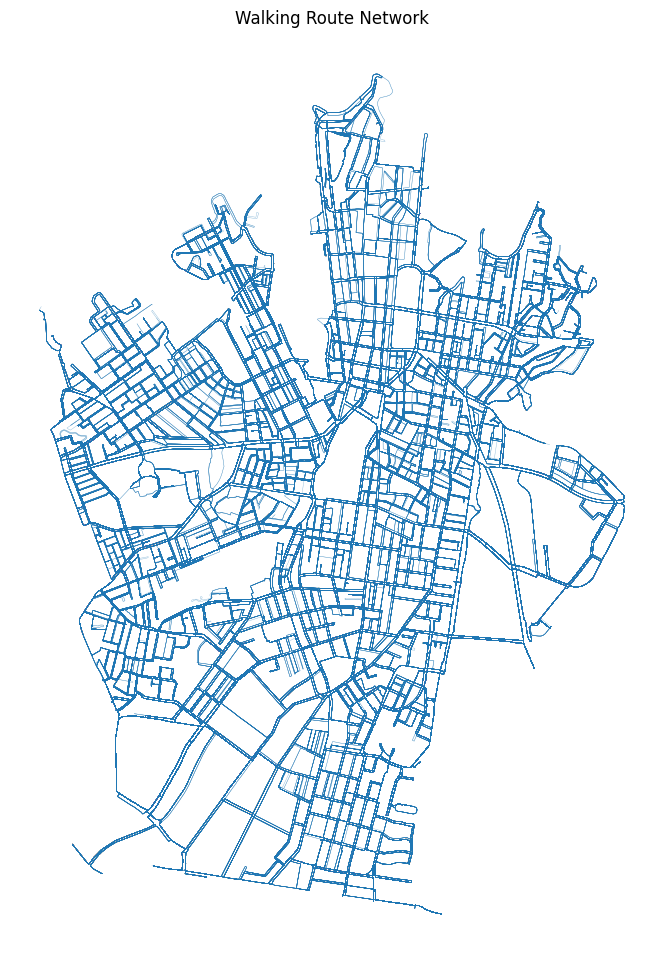

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read network/routes
df_routes = gpd.read_file(
    "output/SYD_total_routes_clogit_keepzeroOD_with_osmnx_fallback.geojson"
)

# plot
fig, ax = plt.subplots(figsize=(12, 12))

df_routes.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.5
)

ax.set_title("Walking Route Network")
ax.set_axis_off()

plt.show()

# OD adjustment
# Delta==0.001


Loading route and Sydney observed-network data...
Transforming observed network from EPSG:3857 to EPSG:7856...
Observed-network rows: 26603
Rows with non-null SiteID: 115
Rows with SiteID = NaN: 26488
Rows with available TotalCount: 115

Preparing directional OD and route data...
Route rows after cleaning: 53422
Directional OD pairs: 11903

Building weekday all-day prior OD vector...
ODs with inconsistent Predicted_Flow across routes: 83
Number of directional OD pairs |Z|: 11903
Total prior weekday all-day demand: 224613.65749845342

Collapsing reverse network rows into physical links...
Original network rows: 26603
Physical two-way links: 13291
Physical links associated with SiteID: 114
Physical links without SiteID: 13177
Physical links without exactly two directed rows: 11

Building one observed record per SiteID...
Unique SiteIDs: 115
Sites connected to more than one physical link: 0
Sites with inconsistent repeated TotalCount values: 0

Exploding route geometries into segments...

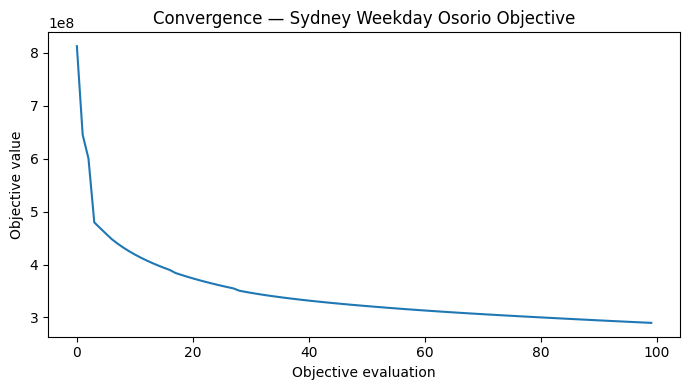


Preparing outputs...

Saving outputs...

Saved:
Physical two-way link flows: output/Sydney_weekday_link_level_flow_two_way_BRI.geojson
Active calibration sites: output/Sydney_weekday_calibration_sites.geojson
All observed sites: output/Sydney_weekday_all_observed_sites.geojson
Physical links without SiteID counts: output/Sydney_weekday_links_without_site_counts.geojson
Calibrated route flows: output/Sydney_weekday_calibrated_route_flows.geojson
Calibrated directional OD demand: output/Sydney_weekday_calibrated_OD_demand.csv
Objective history: output/Sydney_weekday_objective_history.csv
Network diagnostics: output/Sydney_weekday_network_diagnostics.csv
Site diagnostics: output/Sydney_weekday_site_diagnostics.csv
OD prior diagnostics: output/Sydney_weekday_OD_prior_diagnostics.csv


In [6]:


from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import LineString, MultiLineString
from scipy import sparse
from scipy.optimize import least_squares


# ============================================================
# USER SETTINGS
# ============================================================

DELTA = 0.001
MAX_NFEV = 100
EPS = 1e-12

# Route-to-network spatial matching tolerance.
#
# This value must be expressed in the units of the route CRS.
# For a projected CRS in metres:
#
#     BUFFER_TOL = 1.0
#
# means a one-metre route-segment buffer.
BUFFER_TOL = 1.0

ROUTES_PATH = (
    "output/"
    "walking_trips_output_clogit_keepzeroOD_with_osmnx_fallback.geojson"
)

OBS_NET_PATH = (
    "network_with_sites_counts_2025_autumn.gpkg"
)

# Weekday all-day observed count.
FLOW_COL = "TotalCount"

# Zero TotalCount is treated as unavailable count data.
#
# Set to False only when zero is a genuine observed pedestrian
# count rather than a missing-count placeholder.
ZERO_COUNT_MEANS_MISSING = True


# ============================================================
# ROUTE COLUMNS
# ============================================================

ORIGIN_COL = "origin_node"
DESTINATION_COL = "destination_node"
PRIOR_FLOW_COL = "Predicted_Flow"
ROUTE_PROB_COL = "prob"
ROUTE_NUMBER_COL = "route"


# ============================================================
# OBSERVED-NETWORK COLUMNS
# ============================================================

NETWORK_U_COL = "u"
NETWORK_V_COL = "v"
SITE_ID_COL = "SiteID"

# Optional site attributes retained in site outputs when present.
OPTIONAL_SITE_COLUMNS = [
    "Site_ID",
    "Location_x",
    "Location",
    "SiteDescription",
    "distance_to_link",
    "link_id",
    "SiteID_join",
]


# ============================================================
# OUTPUTS
# ============================================================

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_TWO_WAY_LINKS = (
    OUTPUT_DIR
    / "Sydney_weekday_link_level_flow_two_way_BRI.geojson"
)

OUTPUT_CALIBRATION_SITES = (
    OUTPUT_DIR
    / "Sydney_weekday_calibration_sites.geojson"
)

OUTPUT_ALL_SITES = (
    OUTPUT_DIR
    / "Sydney_weekday_all_observed_sites.geojson"
)

OUTPUT_NO_COUNT_LINKS = (
    OUTPUT_DIR
    / "Sydney_weekday_links_without_site_counts.geojson"
)

OUTPUT_ROUTES = (
    OUTPUT_DIR
    / "Sydney_weekday_calibrated_route_flows.geojson"
)

OUTPUT_OD = (
    OUTPUT_DIR
    / "Sydney_weekday_calibrated_OD_demand.csv"
)

OUTPUT_OBJECTIVE = (
    OUTPUT_DIR
    / "Sydney_weekday_objective_history.csv"
)

OUTPUT_NETWORK_DIAGNOSTICS = (
    OUTPUT_DIR
    / "Sydney_weekday_network_diagnostics.csv"
)

OUTPUT_SITE_DIAGNOSTICS = (
    OUTPUT_DIR
    / "Sydney_weekday_site_diagnostics.csv"
)

OUTPUT_PRIOR_DIAGNOSTICS = (
    OUTPUT_DIR
    / "Sydney_weekday_OD_prior_diagnostics.csv"
)


# ============================================================
# HELPER: CHECK REQUIRED COLUMNS
# ============================================================

def require_columns(
    dataframe,
    required_columns,
    dataframe_name,
):
    """
    Raise an error when required columns are missing.
    """
    missing_columns = sorted(
        set(required_columns)
        - set(dataframe.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{dataframe_name} is missing required columns: "
            f"{missing_columns}"
        )


# ============================================================
# HELPER: NORMALISE IDENTIFIERS
# ============================================================

def normalise_identifier(series):
    """
    Convert identifiers to consistent strings.

    Examples:

        66
        66.0
        "66"

    all become:

        "66"

    Missing values remain missing.
    """
    output = pd.Series(
        pd.NA,
        index=series.index,
        dtype="string",
    )

    non_missing_mask = series.notna()

    if not non_missing_mask.any():
        return output

    original_text = (
        series.loc[non_missing_mask]
        .astype(str)
        .str.strip()
    )

    numeric_values = pd.to_numeric(
        series.loc[non_missing_mask],
        errors="coerce",
    )

    output.loc[
        non_missing_mask
    ] = original_text

    numeric_mask = numeric_values.notna()

    numeric_indices = (
        numeric_values.loc[
            numeric_mask
        ].index
    )

    output.loc[
        numeric_indices
    ] = (
        numeric_values.loc[
            numeric_mask
        ]
        .round()
        .astype("Int64")
        .astype(str)
    )

    return output


# ============================================================
# HELPER: EXPLODE ROUTES INTO LINE SEGMENTS
# ============================================================

def explode_route_to_segments(
    route_geometry,
    route_idx,
):
    """
    Split a route LineString or MultiLineString into consecutive
    LineString segments.
    """
    segment_records = []

    if (
        route_geometry is None
        or route_geometry.is_empty
    ):
        return segment_records

    if isinstance(
        route_geometry,
        LineString,
    ):
        line_geometries = [
            route_geometry
        ]

    elif isinstance(
        route_geometry,
        MultiLineString,
    ):
        line_geometries = list(
            route_geometry.geoms
        )

    else:
        return segment_records

    segment_id = 0

    for line_geometry in line_geometries:
        coordinates = list(
            line_geometry.coords
        )

        for point_1, point_2 in zip(
            coordinates[:-1],
            coordinates[1:],
        ):
            segment_geometry = LineString(
                [
                    point_1,
                    point_2,
                ]
            )

            if segment_geometry.length <= 0:
                continue

            segment_records.append(
                {
                    "route_idx": int(
                        route_idx
                    ),
                    "segment_id": int(
                        segment_id
                    ),
                    "geometry": (
                        segment_geometry
                    ),
                }
            )

            segment_id += 1

    return segment_records


# ============================================================
# HELPER: COLLAPSE NETWORK TO PHYSICAL TWO-WAY LINKS
# ============================================================

def build_two_way_physical_network(
    directed_network,
    u_col,
    v_col,
    site_id_col,
):
    """
    Collapse u -> v and v -> u rows into one physical link.

    All SiteIDs associated with either direction are retained.
    """
    network = (
        directed_network
        .copy()
        .reset_index(drop=True)
    )

    network["network_row_id"] = np.arange(
        len(network)
    )

    network["u_norm"] = (
        normalise_identifier(
            network[u_col]
        )
    )

    network["v_norm"] = (
        normalise_identifier(
            network[v_col]
        )
    )

    missing_node_mask = (
        network["u_norm"].isna()
        |
        network["v_norm"].isna()
    )

    if missing_node_mask.any():
        raise ValueError(
            f"{int(missing_node_mask.sum())} network rows "
            "have missing u or v identifiers."
        )

    network["physical_u"] = np.where(
        network["u_norm"]
        <= network["v_norm"],
        network["u_norm"],
        network["v_norm"],
    )

    network["physical_v"] = np.where(
        network["u_norm"]
        <= network["v_norm"],
        network["v_norm"],
        network["u_norm"],
    )

    network["physical_link_key"] = list(
        zip(
            network["physical_u"],
            network["physical_v"],
        )
    )

    network["site_id_norm"] = (
        normalise_identifier(
            network[site_id_col]
        )
    )

    network["has_site_id"] = (
        network["site_id_norm"].notna()
        &
        network["site_id_norm"].ne("")
    )

    physical_records = []

    grouped_network = network.groupby(
        [
            "physical_u",
            "physical_v",
        ],
        sort=False,
        dropna=False,
    )

    for (
        physical_u,
        physical_v,
    ), network_group in grouped_network:

        network_group = (
            network_group.copy()
        )

        representative_row = (
            network_group.iloc[0]
        )

        linked_site_ids = sorted(
            network_group.loc[
                network_group[
                    "has_site_id"
                ],
                "site_id_norm",
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        physical_records.append(
            {
                "physical_u": physical_u,
                "physical_v": physical_v,
                "physical_link_key": (
                    physical_u,
                    physical_v,
                ),
                "directed_row_count": int(
                    len(network_group)
                ),
                "source_network_row_ids": (
                    ",".join(
                        network_group[
                            "network_row_id"
                        ]
                        .astype(str)
                        .tolist()
                    )
                ),
                "site_ids": ",".join(
                    linked_site_ids
                ),
                "number_of_site_ids": int(
                    len(linked_site_ids)
                ),
                "has_site_count_link": (
                    len(linked_site_ids) > 0
                ),
                "geometry": (
                    representative_row.geometry
                ),
            }
        )

    physical_network = gpd.GeoDataFrame(
        physical_records,
        geometry="geometry",
        crs=network.crs,
    )

    physical_network = (
        physical_network
        .reset_index(drop=True)
        .copy()
    )

    physical_network["link_id"] = np.arange(
        len(physical_network)
    )

    physical_key_to_link_id = dict(
        zip(
            physical_network[
                "physical_link_key"
            ],
            physical_network[
                "link_id"
            ],
        )
    )

    network["link_id"] = (
        network["physical_link_key"]
        .map(
            physical_key_to_link_id
        )
        .astype(int)
    )

    network_diagnostics = (
        physical_network[
            [
                "link_id",
                "physical_u",
                "physical_v",
                "directed_row_count",
                "number_of_site_ids",
                "has_site_count_link",
                "site_ids",
                "source_network_row_ids",
            ]
        ]
        .copy()
    )

    return (
        network,
        physical_network,
        network_diagnostics,
    )


# ============================================================
# HELPER: BUILD ONE RECORD PER OBSERVED SITE
# ============================================================

def build_site_observation_table(
    directed_network,
    observed_count_col,
    optional_site_columns=None,
):
    """
    Build one row per SiteID.

    A SiteID may occur on multiple network rows. TotalCount is
    commonly repeated across those rows, so it must not be
    summed repeatedly.

    The median repeated TotalCount is retained as the observed
    site count.

    Each site's associated physical links are stored in:

        linked_physical_link_ids
    """
    if optional_site_columns is None:
        optional_site_columns = []

    count_network = directed_network[
        directed_network[
            "has_site_id"
        ]
    ].copy()

    if count_network.empty:
        raise ValueError(
            "No network rows with non-null SiteID were found."
        )

    site_records = []
    diagnostic_records = []

    for site_id, site_group in (
        count_network.groupby(
            "site_id_norm",
            sort=True,
        )
    ):
        site_group = (
            site_group.copy()
        )

        linked_link_ids = sorted(
            site_group["link_id"]
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )

        count_values = pd.to_numeric(
            site_group[
                observed_count_col
            ],
            errors="coerce",
        ).dropna()

        if len(count_values) == 0:
            observed_count = np.nan
            count_min = np.nan
            count_max = np.nan
            count_nunique = 0
            count_consistent = True

        else:
            observed_count = float(
                count_values.median()
            )

            count_min = float(
                count_values.min()
            )

            count_max = float(
                count_values.max()
            )

            count_nunique = int(
                count_values.nunique()
            )

            count_consistent = bool(
                np.isclose(
                    count_min,
                    count_max,
                    rtol=1e-6,
                    atol=1e-6,
                )
            )

        representative_row = (
            site_group.iloc[0]
        )

        site_record = {
            "site_id": str(
                site_id
            ),
            "flow_obs": (
                observed_count
            ),
            "linked_physical_link_ids": (
                ",".join(
                    map(
                        str,
                        linked_link_ids,
                    )
                )
            ),
            "number_of_linked_physical_links": int(
                len(linked_link_ids)
            ),
            "source_network_row_count": int(
                len(site_group)
            ),
            "source_network_row_ids": (
                ",".join(
                    site_group[
                        "network_row_id"
                    ]
                    .astype(str)
                    .tolist()
                )
            ),
            "count_values_consistent": (
                count_consistent
            ),
            "count_value_min": (
                count_min
            ),
            "count_value_max": (
                count_max
            ),
            "count_value_nunique": (
                count_nunique
            ),
            "geometry": (
                representative_row.geometry
            ),
        }

        for optional_column in (
            optional_site_columns
        ):
            if (
                optional_column
                in site_group.columns
            ):
                available_values = (
                    site_group[
                        optional_column
                    ]
                    .dropna()
                )

                site_record[
                    optional_column
                ] = (
                    available_values.iloc[0]
                    if len(
                        available_values
                    ) > 0
                    else None
                )

        site_records.append(
            site_record
        )

        diagnostic_records.append(
            {
                "site_id": str(
                    site_id
                ),
                "flow_obs": (
                    observed_count
                ),
                "count_values_consistent": (
                    count_consistent
                ),
                "count_value_min": (
                    count_min
                ),
                "count_value_max": (
                    count_max
                ),
                "count_value_nunique": (
                    count_nunique
                ),
                "number_of_source_network_rows": int(
                    len(site_group)
                ),
                "number_of_linked_physical_links": int(
                    len(linked_link_ids)
                ),
                "linked_physical_link_ids": (
                    ",".join(
                        map(
                            str,
                            linked_link_ids,
                        )
                    )
                ),
            }
        )

    sites = gpd.GeoDataFrame(
        site_records,
        geometry="geometry",
        crs=directed_network.crs,
    )

    sites = (
        sites
        .reset_index(drop=True)
        .copy()
    )

    sites["site_row_id"] = np.arange(
        len(sites)
    )

    site_diagnostics = pd.DataFrame(
        diagnostic_records
    )

    return (
        sites,
        site_diagnostics,
    )


# ============================================================
# HELPER: BUILD SITE-TO-PHYSICAL-LINK MATRIX
# ============================================================

def build_site_link_matrix(
    sites,
    number_of_physical_links,
):
    """
    Build sparse matrix B where:

        B[s, i] = 1

    when site s is associated with physical link i.

    Therefore:

        predicted site flow
        =
        B @ predicted physical-link flow
    """
    matrix_rows = []
    matrix_columns = []
    matrix_values = []

    for site_row_id, site_row in (
        sites.iterrows()
    ):
        linked_ids_text = site_row[
            "linked_physical_link_ids"
        ]

        if pd.isna(
            linked_ids_text
        ):
            continue

        linked_link_ids = [
            int(link_id)
            for link_id
            in str(
                linked_ids_text
            ).split(",")
            if str(
                link_id
            ).strip() != ""
        ]

        # Use set to ensure a physical link contributes only
        # once to a given site.
        for link_id in set(
            linked_link_ids
        ):
            matrix_rows.append(
                int(site_row_id)
            )

            matrix_columns.append(
                int(link_id)
            )

            matrix_values.append(
                1.0
            )

    site_link_matrix = sparse.csr_matrix(
        (
            matrix_values,
            (
                matrix_rows,
                matrix_columns,
            ),
        ),
        shape=(
            len(sites),
            number_of_physical_links,
        ),
        dtype=float,
    )

    site_link_matrix.sum_duplicates()

    return site_link_matrix


# ============================================================
# HELPER: MATCH ROUTES TO PHYSICAL LINKS
# ============================================================

def match_routes_to_physical_links(
    route_segments,
    target_links,
    buffer_tolerance,
):
    """
    Spatially match route segments to physical links.

    Direction is deliberately ignored because the target network
    consists of physical two-way links.

    A route contributes at most once to a physical link even if
    multiple route segments intersect the same link.
    """
    if route_segments.empty:
        return {}

    route_segments_match = (
        route_segments.copy()
    )

    route_segments_match[
        "geometry"
    ] = (
        route_segments_match
        .geometry
        .buffer(
            buffer_tolerance
        )
    )

    target_links_match = target_links[
        [
            "link_id",
            "geometry",
        ]
    ].copy()

    matches = gpd.sjoin(
        route_segments_match,
        target_links_match,
        how="inner",
        predicate="intersects",
    )

    if matches.empty:
        return {}

    route_to_links = (
        matches[
            [
                "route_idx",
                "link_id",
            ]
        ]
        .drop_duplicates()
        .groupby(
            "route_idx"
        )["link_id"]
        .apply(list)
        .to_dict()
    )

    return route_to_links


# ============================================================
# HELPER: BUILD PHYSICAL-LINK × OD ASSIGNMENT MATRIX
# ============================================================

def build_route_link_matrix(
    routes,
    target_links,
    route_segments,
    od_to_column,
    number_of_ods,
    buffer_tolerance,
):
    """
    Build sparse physical-link × directional-OD matrix A.

    A[i, j] equals the sum of route probabilities belonging to
    OD j whose route alternatives use physical link i.
    """
    route_to_links = (
        match_routes_to_physical_links(
            route_segments=(
                route_segments
            ),
            target_links=(
                target_links
            ),
            buffer_tolerance=(
                buffer_tolerance
            ),
        )
    )

    matrix_rows = []
    matrix_columns = []
    matrix_values = []

    for route_idx, route_row in (
        routes.iterrows()
    ):
        od_key = route_row[
            "od_key"
        ]

        if od_key not in od_to_column:
            continue

        route_probability = float(
            route_row["prob"]
        )

        if (
            not np.isfinite(
                route_probability
            )
            or route_probability <= 0
        ):
            continue

        od_column = od_to_column[
            od_key
        ]

        matched_link_ids = (
            route_to_links.get(
                int(route_idx),
                [],
            )
        )

        for link_id in (
            matched_link_ids
        ):
            matrix_rows.append(
                int(link_id)
            )

            matrix_columns.append(
                int(od_column)
            )

            matrix_values.append(
                route_probability
            )

    assignment_matrix = sparse.csr_matrix(
        (
            matrix_values,
            (
                matrix_rows,
                matrix_columns,
            ),
        ),
        shape=(
            len(target_links),
            number_of_ods,
        ),
        dtype=float,
    )

    assignment_matrix.sum_duplicates()

    return (
        assignment_matrix,
        route_to_links,
    )


# ============================================================
# 1. LOAD ROUTES AND OBSERVED NETWORK
# ============================================================

print(
    "\nLoading route and Sydney observed-network data..."
)

df_routes = gpd.read_file(
    ROUTES_PATH
)

obs_net_directed_raw = gpd.read_file(
    OBS_NET_PATH
)

require_columns(
    df_routes,
    [
        ORIGIN_COL,
        DESTINATION_COL,
        PRIOR_FLOW_COL,
        ROUTE_PROB_COL,
        "geometry",
    ],
    "Route data",
)

require_columns(
    obs_net_directed_raw,
    [
        NETWORK_U_COL,
        NETWORK_V_COL,
        SITE_ID_COL,
        FLOW_COL,
        "geometry",
    ],
    "Sydney observed network",
)

if df_routes.crs is None:
    raise ValueError(
        "Route data has no CRS."
    )

if obs_net_directed_raw.crs is None:
    raise ValueError(
        "Observed network has no CRS."
    )

if (
    obs_net_directed_raw.crs
    != df_routes.crs
):
    print(
        "Transforming observed network from "
        f"{obs_net_directed_raw.crs} "
        f"to {df_routes.crs}..."
    )

    obs_net_directed_raw = (
        obs_net_directed_raw.to_crs(
            df_routes.crs
        )
    )

if df_routes.crs.is_geographic:
    raise ValueError(
        "The route CRS is geographic. BUFFER_TOL would be "
        "interpreted in degrees. Reproject both datasets to "
        "a projected CRS before calibration."
    )

obs_net_directed_raw[
    FLOW_COL
] = pd.to_numeric(
    obs_net_directed_raw[
        FLOW_COL
    ],
    errors="coerce",
)

print(
    "Observed-network rows:",
    len(obs_net_directed_raw),
)

print(
    "Rows with non-null SiteID:",
    int(
        obs_net_directed_raw[
            SITE_ID_COL
        ].notna().sum()
    ),
)

print(
    "Rows with SiteID = NaN:",
    int(
        obs_net_directed_raw[
            SITE_ID_COL
        ].isna().sum()
    ),
)

print(
    "Rows with available TotalCount:",
    int(
        obs_net_directed_raw[
            FLOW_COL
        ].notna().sum()
    ),
)


# ============================================================
# 2. CLEAN AND PREPARE ROUTE DATA
# ============================================================

print(
    "\nPreparing directional OD and route data..."
)

df_routes = df_routes.copy()

df_routes[
    PRIOR_FLOW_COL
] = pd.to_numeric(
    df_routes[
        PRIOR_FLOW_COL
    ],
    errors="coerce",
)

df_routes[
    ROUTE_PROB_COL
] = pd.to_numeric(
    df_routes[
        ROUTE_PROB_COL
    ],
    errors="coerce",
)

df_routes = (
    df_routes
    .dropna(
        subset=[
            ORIGIN_COL,
            DESTINATION_COL,
            PRIOR_FLOW_COL,
            ROUTE_PROB_COL,
            "geometry",
        ]
    )
    .reset_index(drop=True)
)

df_routes["route_idx"] = np.arange(
    len(df_routes)
)

df_routes[
    "origin_node_norm"
] = normalise_identifier(
    df_routes[
        ORIGIN_COL
    ]
)

df_routes[
    "destination_node_norm"
] = normalise_identifier(
    df_routes[
        DESTINATION_COL
    ]
)

df_routes["od_key"] = list(
    zip(
        df_routes[
            "origin_node_norm"
        ],
        df_routes[
            "destination_node_norm"
        ],
    )
)

# Retain original route probabilities for diagnostics.
df_routes[
    "prob_original"
] = (
    df_routes[
        ROUTE_PROB_COL
    ].astype(float)
)

probability_sum_by_od = (
    df_routes
    .groupby(
        "od_key"
    )[ROUTE_PROB_COL]
    .transform("sum")
)

valid_probability_sum = (
    probability_sum_by_od > EPS
)

df_routes.loc[
    valid_probability_sum,
    "prob",
] = (
    df_routes.loc[
        valid_probability_sum,
        ROUTE_PROB_COL,
    ]
    /
    probability_sum_by_od.loc[
        valid_probability_sum
    ]
)

zero_probability_mask = (
    ~valid_probability_sum
)

zero_probability_ods = (
    df_routes.loc[
        zero_probability_mask,
        "od_key",
    ]
    .drop_duplicates()
    .tolist()
)

if zero_probability_ods:
    print(
        "Directional ODs with probability sum <= 0:",
        len(zero_probability_ods),
    )

    route_count_by_od = (
        df_routes
        .groupby(
            "od_key"
        )["od_key"]
        .transform("size")
    )

    df_routes.loc[
        zero_probability_mask,
        "prob",
    ] = (
        1.0
        /
        route_count_by_od.loc[
            zero_probability_mask
        ]
    )

probability_check = (
    df_routes
    .groupby(
        "od_key"
    )["prob"]
    .sum()
)

maximum_probability_error = float(
    np.abs(
        probability_check
        - 1.0
    ).max()
)

if maximum_probability_error > 1e-8:
    raise RuntimeError(
        "Route probabilities do not sum to one for every "
        "directional OD."
    )

print(
    "Route rows after cleaning:",
    len(df_routes),
)

print(
    "Directional OD pairs:",
    df_routes[
        "od_key"
    ].nunique(),
)


# ============================================================
# 3. CREATE ONE PRIOR VALUE PER DIRECTIONAL OD
# ============================================================

print(
    "\nBuilding weekday all-day prior OD vector..."
)

prior_diagnostics = (
    df_routes
    .groupby(
        "od_key"
    )[PRIOR_FLOW_COL]
    .agg(
        route_rows="size",
        prior_min="min",
        prior_max="max",
        prior_median="median",
        prior_nunique="nunique",
    )
    .reset_index()
)

prior_diagnostics[
    "prior_values_consistent"
] = np.isclose(
    prior_diagnostics[
        "prior_min"
    ],
    prior_diagnostics[
        "prior_max"
    ],
    rtol=1e-5,
    atol=1e-3,
)

inconsistent_prior_ods = (
    prior_diagnostics[
        ~prior_diagnostics[
            "prior_values_consistent"
        ]
    ]
)

print(
    "ODs with inconsistent Predicted_Flow across routes:",
    len(inconsistent_prior_ods),
)

prior_diagnostics_save = (
    prior_diagnostics.copy()
)

prior_diagnostics_save[
    "od_key"
] = (
    prior_diagnostics_save[
        "od_key"
    ].astype(str)
)

prior_diagnostics_save.to_csv(
    OUTPUT_PRIOR_DIAGNOSTICS,
    index=False,
)

od_prior_records = []

for od_key, od_routes in (
    df_routes.groupby(
        "od_key",
        sort=True,
    )
):
    od_routes = (
        od_routes.copy()
    )

    selected_prior = np.nan
    prior_source = None

    # Prefer route 0 when available because Predicted_Flow is
    # normally repeated across alternatives and route 0 is the
    # primary route record.
    if (
        ROUTE_NUMBER_COL
        in od_routes.columns
    ):
        route_number_numeric = pd.to_numeric(
            od_routes[
                ROUTE_NUMBER_COL
            ],
            errors="coerce",
        )

        route_zero_rows = (
            od_routes[
                route_number_numeric == 0
            ]
        )

        if len(route_zero_rows) > 0:
            selected_prior = float(
                route_zero_rows[
                    PRIOR_FLOW_COL
                ].median()
            )

            prior_source = "route_0"

    if not np.isfinite(
        selected_prior
    ):
        selected_prior = float(
            od_routes[
                PRIOR_FLOW_COL
            ].median()
        )

        prior_source = (
            "median_all_routes"
        )

    origin_node, destination_node = (
        od_key
    )

    od_prior_records.append(
        {
            "od_key": od_key,
            "origin_node": (
                origin_node
            ),
            "destination_node": (
                destination_node
            ),
            "prior_flow": max(
                selected_prior,
                0.0,
            ),
            "prior_source": (
                prior_source
            ),
            "number_of_routes": int(
                len(od_routes)
            ),
            "prior_route_min": float(
                od_routes[
                    PRIOR_FLOW_COL
                ].min()
            ),
            "prior_route_max": float(
                od_routes[
                    PRIOR_FLOW_COL
                ].max()
            ),
        }
    )

df_od = pd.DataFrame(
    od_prior_records
)

df_od = (
    df_od
    .sort_values(
        [
            "origin_node",
            "destination_node",
        ]
    )
    .reset_index(drop=True)
)

od_keys = (
    df_od[
        "od_key"
    ].tolist()
)

od_to_j = {
    od_key: column_number
    for column_number, od_key
    in enumerate(od_keys)
}

# Predicted_Flow is already weekday all-day demand.
# No AM_SHARE multiplication is used.
q0 = np.maximum(
    df_od[
        "prior_flow"
    ].to_numpy(
        dtype=float
    ),
    EPS,
)

Z = len(q0)

if Z == 0:
    raise ValueError(
        "No directional OD pairs are available."
    )

print(
    "Number of directional OD pairs |Z|:",
    Z,
)

print(
    "Total prior weekday all-day demand:",
    float(
        q0.sum()
    ),
)


# ============================================================
# 4. COLLAPSE NETWORK INTO PHYSICAL TWO-WAY LINKS
# ============================================================

print(
    "\nCollapsing reverse network rows into physical links..."
)

(
    obs_net_directed,
    obs_net_full,
    network_diagnostics,
) = build_two_way_physical_network(
    directed_network=(
        obs_net_directed_raw
    ),
    u_col=NETWORK_U_COL,
    v_col=NETWORK_V_COL,
    site_id_col=SITE_ID_COL,
)

print(
    "Original network rows:",
    len(obs_net_directed),
)

print(
    "Physical two-way links:",
    len(obs_net_full),
)

print(
    "Physical links associated with SiteID:",
    int(
        obs_net_full[
            "has_site_count_link"
        ].sum()
    ),
)

print(
    "Physical links without SiteID:",
    int(
        (
            ~obs_net_full[
                "has_site_count_link"
            ]
        ).sum()
    ),
)

print(
    "Physical links without exactly two directed rows:",
    int(
        (
            obs_net_full[
                "directed_row_count"
            ]
            != 2
        ).sum()
    ),
)

network_diagnostics.to_csv(
    OUTPUT_NETWORK_DIAGNOSTICS,
    index=False,
)


# ============================================================
# 5. BUILD ONE OBSERVED RECORD PER SITEID
# ============================================================

print(
    "\nBuilding one observed record per SiteID..."
)

(
    sites_all,
    site_diagnostics,
) = build_site_observation_table(
    directed_network=(
        obs_net_directed
    ),
    observed_count_col=(
        FLOW_COL
    ),
    optional_site_columns=(
        OPTIONAL_SITE_COLUMNS
    ),
)

site_diagnostics.to_csv(
    OUTPUT_SITE_DIAGNOSTICS,
    index=False,
)

print(
    "Unique SiteIDs:",
    len(sites_all),
)

print(
    "Sites connected to more than one physical link:",
    int(
        (
            sites_all[
                "number_of_linked_physical_links"
            ]
            > 1
        ).sum()
    ),
)

print(
    "Sites with inconsistent repeated TotalCount values:",
    int(
        (
            ~sites_all[
                "count_values_consistent"
            ]
        ).sum()
    ),
)

if (
    ~sites_all[
        "count_values_consistent"
    ]
).any():
    print(
        "\nWARNING: Some SiteIDs have different TotalCount "
        "values across their linked network rows. The median "
        "value is used. Review the site diagnostics CSV."
    )


# ============================================================
# 6. EXPLODE ROUTES INTO SEGMENTS
# ============================================================

print(
    "\nExploding route geometries into segments..."
)

segment_records = []

for route_idx, route_geometry in enumerate(
    df_routes.geometry
):
    segment_records.extend(
        explode_route_to_segments(
            route_geometry=(
                route_geometry
            ),
            route_idx=route_idx,
        )
    )

route_segments = gpd.GeoDataFrame(
    segment_records,
    geometry="geometry",
    crs=df_routes.crs,
)

print(
    "Route rows:",
    len(df_routes),
)

print(
    "Route segments:",
    len(route_segments),
)

if route_segments.empty:
    raise ValueError(
        "No valid route segments were created."
    )


# ============================================================
# 7. BUILD FULL PHYSICAL-LINK ASSIGNMENT MATRIX
# ============================================================

print(
    "\nBuilding physical-link × OD assignment matrix..."
)

(
    A_full,
    route_to_full_links,
) = build_route_link_matrix(
    routes=df_routes,
    target_links=obs_net_full,
    route_segments=route_segments,
    od_to_column=od_to_j,
    number_of_ods=Z,
    buffer_tolerance=BUFFER_TOL,
)

print(
    "A_full shape:",
    A_full.shape,
)

print(
    "A_full non-zero entries:",
    A_full.nnz,
)

# Number of non-zero OD assignment coefficients in each
# physical-link row.
physical_row_coverage = np.diff(
    A_full.indptr
)

obs_net_full[
    "route_coverage_count"
] = physical_row_coverage

obs_net_full[
    "has_route_coverage"
] = (
    obs_net_full[
        "route_coverage_count"
    ] > 0
)

print(
    "Physical links with route coverage:",
    int(
        obs_net_full[
            "has_route_coverage"
        ].sum()
    ),
)

print(
    "Physical links without route coverage:",
    int(
        (
            ~obs_net_full[
                "has_route_coverage"
            ]
        ).sum()
    ),
)


# ============================================================
# 8. BUILD SITE-TO-LINK AND SITE-TO-OD MATRICES
# ============================================================

print(
    "\nBuilding observed-site × physical-link matrix..."
)

B_all = build_site_link_matrix(
    sites=sites_all,
    number_of_physical_links=(
        len(obs_net_full)
    ),
)

print(
    "B_all shape:",
    B_all.shape,
)

print(
    "B_all non-zero entries:",
    B_all.nnz,
)

# This implements the original logic:
#
#     np.sum(
#         links.loc[
#             linked_link_ids,
#             "flow"
#         ]
#     )
#
# for every SiteID.
A_site_all = (
    B_all @ A_full
).tocsr()

print(
    "A_site_all shape:",
    A_site_all.shape,
)

print(
    "A_site_all non-zero entries:",
    A_site_all.nnz,
)

site_route_coverage_count = np.diff(
    A_site_all.indptr
)

sites_all[
    "route_coverage_count"
] = site_route_coverage_count

sites_all[
    "has_route_coverage"
] = (
    sites_all[
        "route_coverage_count"
    ] > 0
)


# ============================================================
# 9. IDENTIFY ACTIVE CALIBRATION SITES
# ============================================================

valid_observed_count_mask = (
    sites_all[
        "flow_obs"
    ].notna()
)

if ZERO_COUNT_MEANS_MISSING:
    valid_observed_count_mask &= (
        sites_all[
            "flow_obs"
        ] > 0
    )

else:
    valid_observed_count_mask &= (
        sites_all[
            "flow_obs"
        ] >= 0
    )

active_calibration_mask = (
    valid_observed_count_mask
    &
    sites_all[
        "has_route_coverage"
    ]
    &
    (
        sites_all[
            "number_of_linked_physical_links"
        ] > 0
    )
)

sites_all[
    "has_valid_observed_count"
] = valid_observed_count_mask

sites_all[
    "used_for_calibration"
] = active_calibration_mask

sites_all[
    "calibration_status"
] = np.select(
    [
        active_calibration_mask,

        valid_observed_count_mask
        &
        ~sites_all[
            "has_route_coverage"
        ],

        ~valid_observed_count_mask
        &
        sites_all[
            "has_route_coverage"
        ],

        ~valid_observed_count_mask
        &
        ~sites_all[
            "has_route_coverage"
        ],
    ],
    [
        "observed_and_used",
        "observed_no_route_coverage",
        "missing_count_route_covered",
        "missing_count_no_route_coverage",
    ],
    default="unknown",
)

print(
    "\nSites with valid TotalCount:",
    int(
        valid_observed_count_mask.sum()
    ),
)

print(
    "Observed sites without route coverage:",
    int(
        (
            valid_observed_count_mask
            &
            ~sites_all[
                "has_route_coverage"
            ]
        ).sum()
    ),
)

print(
    "Active calibration sites:",
    int(
        active_calibration_mask.sum()
    ),
)

if (
    active_calibration_mask.sum()
    == 0
):
    raise ValueError(
        "No observed sites have route coverage. Check the CRS, "
        "BUFFER_TOL, route geometries, SiteID mapping and "
        "TotalCount field."
    )

active_site_indices = np.flatnonzero(
    active_calibration_mask.to_numpy()
)

A_cal = A_site_all[
    active_site_indices,
    :
].tocsr()

sites_cal = (
    sites_all.loc[
        active_calibration_mask
    ]
    .copy()
    .reset_index(drop=True)
)

sites_cal[
    "calibration_site_id"
] = np.arange(
    len(sites_cal)
)

y = sites_cal[
    "flow_obs"
].to_numpy(
    dtype=float
)

I = len(y)

print(
    "A_cal shape:",
    A_cal.shape,
)

print(
    "A_cal non-zero entries:",
    A_cal.nnz,
)

print(
    "Number of calibration equations |I|:",
    I,
)


# ============================================================
# 10. CONSTRUCT OSORIO OBJECTIVE
# ============================================================

print(
    "\nConstructing Osorio objective..."
)

w_y = np.sqrt(
    1.0 / I
)

w_q = np.sqrt(
    DELTA / Z
)

A_aug = sparse.vstack(
    [
        w_y * A_cal,

        w_q
        *
        sparse.identity(
            Z,
            format="csr",
        ),
    ],
    format="csr",
)

b_aug = np.concatenate(
    [
        w_y * y,
        w_q * q0,
    ]
)


def objective_osorio(
    q_vector,
):
    """
    Osorio objective:

        (1/I) * sum((A_cal q - y)^2)
        +
        (DELTA/Z) * sum((q - q0)^2)
    """
    count_fit_component = (
        (1.0 / I)
        *
        np.sum(
            (
                A_cal @ q_vector
                -
                y
            )
            ** 2
        )
    )

    prior_component = (
        (DELTA / Z)
        *
        np.sum(
            (
                q_vector
                -
                q0
            )
            ** 2
        )
    )

    return float(
        count_fit_component
        +
        prior_component
    )


def objective_components(
    q_vector,
):
    """
    Return the count-fit and prior-penalty components.
    """
    count_fit_component = (
        (1.0 / I)
        *
        np.sum(
            (
                A_cal @ q_vector
                -
                y
            )
            ** 2
        )
    )

    prior_component = (
        (DELTA / Z)
        *
        np.sum(
            (
                q_vector
                -
                q0
            )
            ** 2
        )
    )

    return (
        float(
            count_fit_component
        ),
        float(
            prior_component
        ),
    )


# ============================================================
# 11. SOLVE NON-NEGATIVE CALIBRATION
# ============================================================

print(
    "\nSolving non-negative Osorio calibration..."
)

lower_bound = np.zeros(
    Z,
    dtype=float,
)

upper_bound = np.full(
    Z,
    np.inf,
    dtype=float,
)

initial_demand = np.maximum(
    q0,
    0.0,
)

objective_history = []

last_evaluated_x = {
    "value": None
}


def residual_logged(
    q_vector,
):
    """
    Residual supplied to scipy.optimize.least_squares.

    Squaring the residual produces the Osorio objective.
    """
    previous_x = (
        last_evaluated_x[
            "value"
        ]
    )

    if (
        previous_x is None
        or not np.array_equal(
            q_vector,
            previous_x,
        )
    ):
        (
            count_component,
            prior_component,
        ) = objective_components(
            q_vector
        )

        objective_history.append(
            {
                "evaluation": len(
                    objective_history
                ),
                "objective": (
                    count_component
                    +
                    prior_component
                ),
                "count_fit_component": (
                    count_component
                ),
                "prior_component": (
                    prior_component
                ),
            }
        )

        last_evaluated_x[
            "value"
        ] = q_vector.copy()

    return (
        A_aug @ q_vector
        -
        b_aug
    )


def jacobian(
    _q_vector,
):
    """
    Exact Jacobian because the residual is linear in q.
    """
    return A_aug


result = least_squares(
    residual_logged,
    x0=initial_demand,
    jac=jacobian,
    bounds=(
        lower_bound,
        upper_bound,
    ),
    method="trf",
    max_nfev=MAX_NFEV,
    ftol=1e-9,
    xtol=1e-9,
    gtol=1e-9,
    verbose=2,
)

q_hat = np.maximum(
    result.x,
    0.0,
)


# ============================================================
# 12. CALIBRATED DIRECTIONAL OD DEMAND
# ============================================================

df_od[
    "calibrated_flow"
] = q_hat

df_od[
    "absolute_adjustment"
] = (
    df_od[
        "calibrated_flow"
    ]
    -
    df_od[
        "prior_flow"
    ]
)

df_od[
    "adjustment_ratio"
] = np.where(
    df_od[
        "prior_flow"
    ] > EPS,
    (
        df_od[
            "calibrated_flow"
        ]
        /
        df_od[
            "prior_flow"
        ]
    ),
    np.nan,
)

df_od[
    "percentage_change"
] = np.where(
    df_od[
        "prior_flow"
    ] > EPS,
    100.0
    *
    (
        df_od[
            "calibrated_flow"
        ]
        -
        df_od[
            "prior_flow"
        ]
    )
    /
    df_od[
        "prior_flow"
    ],
    np.nan,
)

df_od[
    "demand_changed"
] = ~np.isclose(
    df_od[
        "calibrated_flow"
    ],
    df_od[
        "prior_flow"
    ],
    rtol=1e-8,
    atol=1e-8,
)


# ============================================================
# 13. CALIBRATED ROUTE FLOWS
# ============================================================

prior_od_lookup = dict(
    zip(
        df_od[
            "od_key"
        ],
        df_od[
            "prior_flow"
        ],
    )
)

calibrated_od_lookup = dict(
    zip(
        df_od[
            "od_key"
        ],
        df_od[
            "calibrated_flow"
        ],
    )
)

df_routes[
    "OD_demand_prior"
] = (
    df_routes[
        "od_key"
    ].map(
        prior_od_lookup
    )
)

df_routes[
    "OD_demand_calibrated"
] = (
    df_routes[
        "od_key"
    ].map(
        calibrated_od_lookup
    )
)

df_routes[
    "route_flow_prior"
] = (
    df_routes[
        "OD_demand_prior"
    ]
    *
    df_routes[
        "prob"
    ]
)

df_routes[
    "route_flow_calibrated"
] = (
    df_routes[
        "OD_demand_calibrated"
    ]
    *
    df_routes[
        "prob"
    ]
)

df_routes[
    "route_flow_adjustment"
] = (
    df_routes[
        "route_flow_calibrated"
    ]
    -
    df_routes[
        "route_flow_prior"
    ]
)


# ============================================================
# 14. PHYSICAL TWO-WAY LINK FLOWS
# ============================================================

print(
    "\nCalculating physical two-way link flows..."
)

flow_prior_full = np.asarray(
    A_full @ q0,
    dtype=float,
).reshape(-1)

flow_hat_full = np.asarray(
    A_full @ q_hat,
    dtype=float,
).reshape(-1)

obs_net_full[
    "flow_prior"
] = flow_prior_full

obs_net_full[
    "flow_hat"
] = flow_hat_full

obs_net_full[
    "flow_adjustment"
] = (
    obs_net_full[
        "flow_hat"
    ]
    -
    obs_net_full[
        "flow_prior"
    ]
)

obs_net_full[
    "flow_change_ratio"
] = np.where(
    obs_net_full[
        "flow_prior"
    ] > EPS,
    (
        obs_net_full[
            "flow_hat"
        ]
        /
        obs_net_full[
            "flow_prior"
        ]
    ),
    np.nan,
)

obs_net_full[
    "flow_percentage_change"
] = np.where(
    obs_net_full[
        "flow_prior"
    ] > EPS,
    100.0
    *
    (
        obs_net_full[
            "flow_hat"
        ]
        -
        obs_net_full[
            "flow_prior"
        ]
    )
    /
    obs_net_full[
        "flow_prior"
    ],
    np.nan,
)

obs_net_full[
    "flow_changed"
] = ~np.isclose(
    obs_net_full[
        "flow_prior"
    ],
    obs_net_full[
        "flow_hat"
    ],
    rtol=1e-8,
    atol=1e-8,
)

obs_net_full[
    "final_flow_basis"
] = np.where(
    obs_net_full[
        "has_site_count_link"
    ],
    "calibrated_model_site_link",
    "calibrated_model_no_site_count",
)


# ============================================================
# 15. SITE-LEVEL PRIOR AND CALIBRATED FLOWS
# ============================================================

print(
    "\nCalculating site-level prior and calibrated flows..."
)

site_flow_prior_all = np.asarray(
    A_site_all @ q0,
    dtype=float,
).reshape(-1)

site_flow_hat_all = np.asarray(
    A_site_all @ q_hat,
    dtype=float,
).reshape(-1)

sites_all[
    "flow_prior"
] = site_flow_prior_all

sites_all[
    "flow_hat"
] = site_flow_hat_all

sites_all[
    "flow_adjustment"
] = (
    sites_all[
        "flow_hat"
    ]
    -
    sites_all[
        "flow_prior"
    ]
)

sites_all[
    "residual"
] = np.where(
    sites_all[
        "has_valid_observed_count"
    ],
    (
        sites_all[
            "flow_hat"
        ]
        -
        sites_all[
            "flow_obs"
        ]
    ),
    np.nan,
)

sites_all[
    "absolute_residual"
] = np.where(
    sites_all[
        "has_valid_observed_count"
    ],
    np.abs(
        sites_all[
            "residual"
        ]
    ),
    np.nan,
)

sites_all[
    "relative_error"
] = np.where(
    sites_all[
        "has_valid_observed_count"
    ]
    &
    (
        sites_all[
            "flow_obs"
        ] > 0
    ),
    (
        sites_all[
            "residual"
        ]
        /
        sites_all[
            "flow_obs"
        ]
    ),
    np.nan,
)

sites_all[
    "absolute_percentage_error"
] = np.where(
    sites_all[
        "has_valid_observed_count"
    ]
    &
    (
        sites_all[
            "flow_obs"
        ] > 0
    ),
    100.0
    *
    np.abs(
        sites_all[
            "residual"
        ]
        /
        sites_all[
            "flow_obs"
        ]
    ),
    np.nan,
)

# Recreate active-site output after adding modelled-flow fields.
sites_cal = (
    sites_all.loc[
        active_calibration_mask
    ]
    .copy()
    .reset_index(drop=True)
)

sites_cal[
    "calibration_site_id"
] = np.arange(
    len(sites_cal)
)


# ============================================================
# 16. LINKS WITHOUT OBSERVED SITE COUNTS
# ============================================================

no_count_links = (
    obs_net_full[
        ~obs_net_full[
            "has_site_count_link"
        ]
    ]
    .copy()
)

no_count_links[
    "flow_unchanged"
] = np.isclose(
    no_count_links[
        "flow_prior"
    ],
    no_count_links[
        "flow_hat"
    ],
    rtol=1e-8,
    atol=1e-8,
)

print(
    "\n--- Links without SiteID counts ---"
)

print(
    "Physical links without SiteID:",
    len(no_count_links),
)

print(
    "No-count links unchanged after calibration:",
    int(
        no_count_links[
            "flow_unchanged"
        ].sum()
    ),
)

print(
    "No-count links changed because related OD demand changed:",
    int(
        (
            ~no_count_links[
                "flow_unchanged"
            ]
        ).sum()
    ),
)

if len(no_count_links) > 0:
    maximum_no_count_adjustment = float(
        no_count_links[
            "flow_adjustment"
        ]
        .abs()
        .max()
    )
else:
    maximum_no_count_adjustment = 0.0

print(
    "Maximum absolute adjustment on no-count links:",
    maximum_no_count_adjustment,
)


# ============================================================
# 17. FINAL OBJECTIVE AND CALIBRATION SUMMARY
# ============================================================

J_final = objective_osorio(
    q_hat
)

(
    count_fit_final,
    prior_penalty_final,
) = objective_components(
    q_hat
)

print(
    "\n=========================================="
)

print(
    "SYDNEY WEEKDAY ALL-DAY CALIBRATION SUMMARY"
)

print(
    "=========================================="
)

print(
    "Solver success:",
    result.success,
)

print(
    "Solver status:",
    result.status,
)

print(
    "Solver message:",
    result.message,
)

print(
    "Function evaluations:",
    result.nfev,
)

print(
    "Recorded objective evaluations:",
    len(objective_history),
)

print(
    "\n--- Osorio objective ---"
)

print(
    "Final objective:",
    float(J_final),
)

print(
    "Final observed-count fit component:",
    count_fit_final,
)

print(
    "Final prior-penalty component:",
    prior_penalty_final,
)

print(
    "\n--- Count-site diagnostics ---"
)

print(
    "All unique SiteIDs:",
    len(sites_all),
)

print(
    "Sites with valid TotalCount:",
    int(
        valid_observed_count_mask.sum()
    ),
)

print(
    "Active calibration sites:",
    len(sites_cal),
)

print(
    "Observed sites without route coverage:",
    int(
        (
            valid_observed_count_mask
            &
            ~sites_all[
                "has_route_coverage"
            ]
        ).sum()
    ),
)

print(
    "\n--- Demand totals ---"
)

print(
    "Total prior weekday demand:",
    float(
        q0.sum()
    ),
)

print(
    "Total calibrated weekday demand:",
    float(
        q_hat.sum()
    ),
)

print(
    "Total demand adjustment:",
    float(
        q_hat.sum()
        -
        q0.sum()
    ),
)

print(
    "Number of OD demands changed:",
    int(
        df_od[
            "demand_changed"
        ].sum()
    ),
)

print(
    "Number of calibrated OD demands equal to zero:",
    int(
        np.isclose(
            df_od[
                "calibrated_flow"
            ],
            0.0,
            atol=1e-10,
        ).sum()
    ),
)


# ============================================================
# 18. CONVERGENCE PLOT
# ============================================================

history_df = pd.DataFrame(
    objective_history
)

if not history_df.empty:
    plt.figure(
        figsize=(
            7,
            4,
        )
    )

    plt.plot(
        history_df[
            "evaluation"
        ],
        history_df[
            "objective"
        ],
    )

    plt.title(
        "Convergence — Sydney Weekday Osorio Objective"
    )

    plt.xlabel(
        "Objective evaluation"
    )

    plt.ylabel(
        "Objective value"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. PREPARE OUTPUTS
# ============================================================

print(
    "\nPreparing outputs..."
)

obs_net_full_save = (
    obs_net_full.copy()
)

sites_all_save = (
    sites_all.copy()
)

sites_cal_save = (
    sites_cal.copy()
)

no_count_links_save = (
    no_count_links.copy()
)

df_routes_save = (
    df_routes.copy()
)

df_od_save = (
    df_od.copy()
)

# GeoJSON does not reliably support tuple-valued fields.
for output_gdf in [
    obs_net_full_save,
    sites_all_save,
    sites_cal_save,
    no_count_links_save,
    df_routes_save,
]:
    if (
        "physical_link_key"
        in output_gdf.columns
    ):
        output_gdf[
            "physical_link_key"
        ] = (
            output_gdf[
                "physical_link_key"
            ]
            .astype(str)
        )

    if (
        "od_key"
        in output_gdf.columns
    ):
        output_gdf[
            "od_key"
        ] = (
            output_gdf[
                "od_key"
            ]
            .astype(str)
        )

for output_gdf in [
    obs_net_full_save,
    sites_all_save,
    sites_cal_save,
    no_count_links_save,
]:
    if (
        "source_network_row_ids"
        in output_gdf.columns
    ):
        output_gdf[
            "source_network_row_ids"
        ] = (
            output_gdf[
                "source_network_row_ids"
            ]
            .astype(str)
        )

df_od_save[
    "od_key"
] = (
    df_od_save[
        "od_key"
    ].astype(str)
)


# ============================================================
# 20. SAVE OUTPUTS
# ============================================================

print(
    "\nSaving outputs..."
)

obs_net_full_save.to_file(
    OUTPUT_TWO_WAY_LINKS,
    driver="GeoJSON",
)

sites_cal_save.to_file(
    OUTPUT_CALIBRATION_SITES,
    driver="GeoJSON",
)

sites_all_save.to_file(
    OUTPUT_ALL_SITES,
    driver="GeoJSON",
)

no_count_links_save.to_file(
    OUTPUT_NO_COUNT_LINKS,
    driver="GeoJSON",
)

df_routes_save.to_file(
    OUTPUT_ROUTES,
    driver="GeoJSON",
)

df_od_save.to_csv(
    OUTPUT_OD,
    index=False,
)

history_df.to_csv(
    OUTPUT_OBJECTIVE,
    index=False,
)


# ============================================================
# 21. SAVED-FILE SUMMARY
# ============================================================

print(
    "\nSaved:"
)

print(
    "Physical two-way link flows:",
    OUTPUT_TWO_WAY_LINKS,
)

print(
    "Active calibration sites:",
    OUTPUT_CALIBRATION_SITES,
)

print(
    "All observed sites:",
    OUTPUT_ALL_SITES,
)

print(
    "Physical links without SiteID counts:",
    OUTPUT_NO_COUNT_LINKS,
)

print(
    "Calibrated route flows:",
    OUTPUT_ROUTES,
)

print(
    "Calibrated directional OD demand:",
    OUTPUT_OD,
)

print(
    "Objective history:",
    OUTPUT_OBJECTIVE,
)

print(
    "Network diagnostics:",
    OUTPUT_NETWORK_DIAGNOSTICS,
)

print(
    "Site diagnostics:",
    OUTPUT_SITE_DIAGNOSTICS,
)

print(
    "OD prior diagnostics:",
    OUTPUT_PRIOR_DIAGNOSTICS,
)

Using sites_all from the previous OD-calibration cell.

SYDNEY WEEKDAY ALL-DAY SITE VALIDATION
Number of sites used for validation: 114

--- Before calibration ---
R²: -0.5743
RMSE: 28503.2955
MAE: 17132.6915
Observed total: 2016960.0
Predicted total: 69788.1179

--- After calibration ---
R²: 0.4384
RMSE: 17024.2474
MAE: 8609.2098
Observed total: 2016960.0
Predicted total: 1166938.2254

Sites improved after calibration: 108 out of 114


,model,number_of_sites,R2,RMSE,MAE,observed_total,predicted_total,observed_mean,predicted_mean
0,Before calibration,114,-0.5743,28503.2955,17132.6915,2016960.0,6.978812e+04,17692.6316,612.1765
1,After calibration,114,0.4384,17024.2474,8609.2098,2016960.0,1.166938e+06,17692.6316,10236.3002


,site_id,flow_obs,flow_prior,flow_hat,y_observed,y_predicted_prior,y_predicted,prior_residual,residual,prior_absolute_error,absolute_error,absolute_error_improvement,relative_error,absolute_percentage_error,number_of_linked_physical_links,route_coverage_count,has_route_coverage,used_for_calibration,calibration_status
47,36,111972.0,18.756180,7059.615649,111972.0,18.756180,7059.615649,-111953.243820,-104912.384351,111953.243820,104912.384351,7040.859469,-0.936952,93.695196,1,10,True,True,observed_and_used
44,33,79758.0,91.297166,10631.696952,79758.0,91.297166,10631.696952,-79666.702834,-69126.303048,79666.702834,69126.303048,10540.399786,-0.866701,86.670056,1,21,True,True,observed_and_used
43,32,62424.0,46.471815,9187.839086,62424.0,46.471815,9187.839086,-62377.528185,-53236.160914,62377.528185,53236.160914,9141.367271,-0.852816,85.281560,1,12,True,True,observed_and_used
5,105,91914.0,173.539594,41507.997234,91914.0,173.539594,41507.997234,-91740.460406,-50406.002766,91740.460406,50406.002766,41334.457640,-0.548404,54.840397,1,72,True,True,observed_and_used
55,43,71028.0,748.838476,29809.154555,71028.0,748.838476,29809.154555,-70279.161524,-41218.845445,70279.161524,41218.845445,29060.316079,-0.580318,58.031826,1,48,True,True,observed_and_used
62,50,46416.0,134.950635,10592.241303,46416.0,134.950635,10592.241303,-46281.049365,-35823.758697,46281.049365,35823.758697,10457.290668,-0.771798,77.179763,1,20,True,True,observed_and_used
49,38,61596.0,459.004928,34875.711128,61596.0,459.004928,34875.711128,-61136.995072,-26720.288872,61136.995072,26720.288872,34416.706199,-0.433799,43.379909,1,36,True,True,observed_and_used
57,45,42624.0,146.221524,15904.301598,42624.0,146.221524,15904.301598,-42477.778476,-26719.698402,42477.778476,26719.698402,15758.080075,-0.626870,62.686980,1,84,True,True,observed_and_used
4,104,35742.0,46.471815,9187.839086,35742.0,46.471815,9187.839086,-35695.528185,-26554.160914,35695.528185,26554.160914,9141.367271,-0.742940,74.293998,1,12,True,True,observed_and_used
19,119,34050.0,46.471815,9187.839086,34050.0,46.471815,9187.839086,-34003.528185,-24862.160914,34003.528185,24862.160914,9141.367271,-0.730166,73.016625,1,12,True,True,observed_and_used


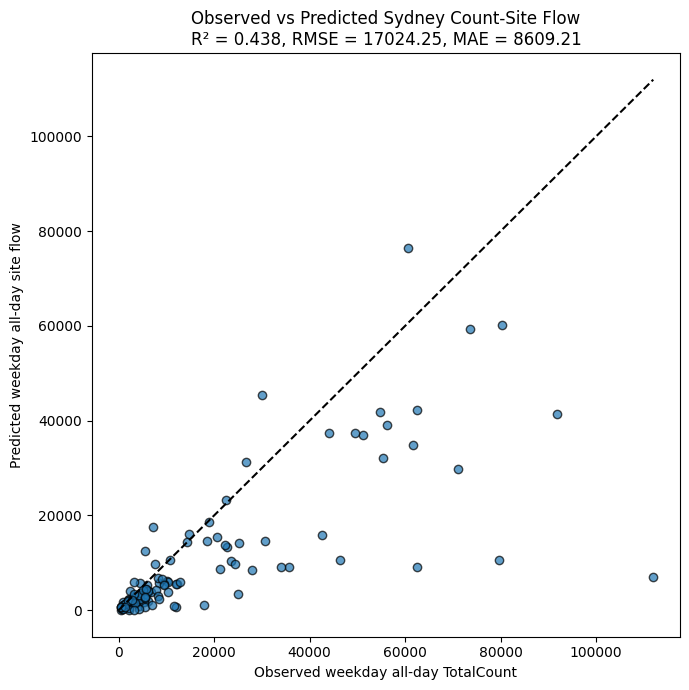


Site-level validation results saved to: output/Sydney_weekday_site_validation_metrics.csv
Metric summary saved to: output/Sydney_weekday_site_validation_summary.csv


In [7]:
# ============================================================
# VALIDATION METRICS 
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)


# ============================================================
# SETTINGS
# ============================================================

VALIDATION_OUTPUT = Path(
    "output/Sydney_weekday_site_validation_metrics.csv"
)

METRIC_SUMMARY_OUTPUT = Path(
    "output/Sydney_weekday_site_validation_summary.csv"
)

SITE_ID_COL = "site_id"
OBSERVED_COL = "flow_obs"
PREDICTED_COL = "flow_hat"
PRIOR_PREDICTED_COL = "flow_prior"

HAS_COUNT_COL = "has_valid_observed_count"
HAS_ROUTE_COVERAGE_COL = "has_route_coverage"
USED_FOR_CALIBRATION_COL = "used_for_calibration"

EPS = 1e-12


# ============================================================
# 1. CREATE VALIDATION TABLE
# ============================================================

validation_sites = (
    sites_all
    .copy()
    .reset_index(drop=True)
)

print(
    "Using sites_all from the previous OD-calibration cell."
)


# ============================================================
# 2. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = {
    SITE_ID_COL,
    OBSERVED_COL,
    PREDICTED_COL,
    PRIOR_PREDICTED_COL,
    HAS_COUNT_COL,
    HAS_ROUTE_COVERAGE_COL,
    USED_FOR_CALIBRATION_COL,
}

missing_columns = (
    required_columns
    -
    set(validation_sites.columns)
)

if missing_columns:
    raise ValueError(
        "sites_all is missing required validation columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# 3. CLEAN DATA TYPES
# ============================================================

for column in [
    OBSERVED_COL,
    PREDICTED_COL,
    PRIOR_PREDICTED_COL,
]:
    validation_sites[column] = pd.to_numeric(
        validation_sites[column],
        errors="coerce",
    )


def convert_to_boolean(series):
    """
    Convert Boolean, numeric and text representations to Boolean.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(
            [
                "true",
                "1",
                "yes",
            ]
        )
    )


for column in [
    HAS_COUNT_COL,
    HAS_ROUTE_COVERAGE_COL,
    USED_FOR_CALIBRATION_COL,
]:
    validation_sites[column] = convert_to_boolean(
        validation_sites[column]
    )


# ============================================================
# 4. CLEAN TINY NEGATIVE PREDICTIONS
# ============================================================

validation_sites.loc[
    validation_sites[PREDICTED_COL] < 0,
    PREDICTED_COL,
] = 0.0

validation_sites.loc[
    validation_sites[PRIOR_PREDICTED_COL] < 0,
    PRIOR_PREDICTED_COL,
] = 0.0


# ============================================================
# 5. KEEP SITES USED IN THE CALIBRATION
# ============================================================

validation_mask = (
    validation_sites[HAS_COUNT_COL]
    &
    validation_sites[HAS_ROUTE_COVERAGE_COL]
    &
    validation_sites[USED_FOR_CALIBRATION_COL]
    &
    validation_sites[OBSERVED_COL].notna()
    &
    validation_sites[PREDICTED_COL].notna()
    &
    validation_sites[PRIOR_PREDICTED_COL].notna()
    &
    (validation_sites[OBSERVED_COL] > 0)
)

validation_sites = (
    validation_sites.loc[
        validation_mask
    ]
    .copy()
    .reset_index(drop=True)
)

if validation_sites.empty:
    raise ValueError(
        "No calibration sites with positive TotalCount and "
        "valid prior/calibrated predictions were found."
    )


# ============================================================
# 6. DEFINE OBSERVED AND PREDICTED VALUES
# ============================================================

validation_sites["y_observed"] = (
    validation_sites[OBSERVED_COL]
    .astype(float)
)

validation_sites["y_predicted_prior"] = (
    validation_sites[PRIOR_PREDICTED_COL]
    .astype(float)
)

validation_sites["y_predicted"] = (
    validation_sites[PREDICTED_COL]
    .astype(float)
)

y_observed = validation_sites[
    "y_observed"
].to_numpy(dtype=float)

y_predicted_prior = validation_sites[
    "y_predicted_prior"
].to_numpy(dtype=float)

y_predicted = validation_sites[
    "y_predicted"
].to_numpy(dtype=float)


# ============================================================
# 7. CALCULATE AFTER-CALIBRATION ERRORS
# ============================================================

validation_sites["residual"] = (
    validation_sites["y_predicted"]
    -
    validation_sites["y_observed"]
)

validation_sites["absolute_error"] = np.abs(
    validation_sites["residual"]
)

validation_sites["squared_error"] = (
    validation_sites["residual"] ** 2
)

validation_sites["relative_error"] = (
    validation_sites["residual"]
    /
    validation_sites["y_observed"]
)

validation_sites["absolute_percentage_error"] = (
    100.0
    *
    validation_sites["absolute_error"]
    /
    validation_sites["y_observed"]
)


# ============================================================
# 8. CALCULATE BEFORE-CALIBRATION ERRORS
# ============================================================

validation_sites["prior_residual"] = (
    validation_sites["y_predicted_prior"]
    -
    validation_sites["y_observed"]
)

validation_sites["prior_absolute_error"] = np.abs(
    validation_sites["prior_residual"]
)

validation_sites["prior_squared_error"] = (
    validation_sites["prior_residual"] ** 2
)

validation_sites["prior_relative_error"] = (
    validation_sites["prior_residual"]
    /
    validation_sites["y_observed"]
)

validation_sites[
    "prior_absolute_percentage_error"
] = (
    100.0
    *
    validation_sites["prior_absolute_error"]
    /
    validation_sites["y_observed"]
)

validation_sites["absolute_error_improvement"] = (
    validation_sites["prior_absolute_error"]
    -
    validation_sites["absolute_error"]
)

validation_sites["calibration_improved_site"] = (
    validation_sites["absolute_error"]
    <
    validation_sites["prior_absolute_error"]
)


# ============================================================
# 9. CALCULATE AFTER-CALIBRATION METRICS
# ============================================================

if (
    len(y_observed) < 2
    or np.isclose(
        np.var(y_observed),
        0.0,
    )
):
    r2_calibrated = np.nan

else:
    r2_calibrated = r2_score(
        y_observed,
        y_predicted,
    )

rmse_calibrated = np.sqrt(
    mean_squared_error(
        y_observed,
        y_predicted,
    )
)

mae_calibrated = mean_absolute_error(
    y_observed,
    y_predicted,
)


# ============================================================
# 10. CALCULATE BEFORE-CALIBRATION METRICS
# ============================================================

if (
    len(y_observed) < 2
    or np.isclose(
        np.var(y_observed),
        0.0,
    )
):
    r2_prior = np.nan

else:
    r2_prior = r2_score(
        y_observed,
        y_predicted_prior,
    )

rmse_prior = np.sqrt(
    mean_squared_error(
        y_observed,
        y_predicted_prior,
    )
)

mae_prior = mean_absolute_error(
    y_observed,
    y_predicted_prior,
)


# ============================================================
# 11. CREATE METRIC SUMMARY
# ============================================================

metric_summary = pd.DataFrame(
    [
        {
            "model": "Before calibration",
            "number_of_sites": len(
                validation_sites
            ),
            "R2": r2_prior,
            "RMSE": rmse_prior,
            "MAE": mae_prior,
            "observed_total": float(
                y_observed.sum()
            ),
            "predicted_total": float(
                y_predicted_prior.sum()
            ),
            "observed_mean": float(
                y_observed.mean()
            ),
            "predicted_mean": float(
                y_predicted_prior.mean()
            ),
        },
        {
            "model": "After calibration",
            "number_of_sites": len(
                validation_sites
            ),
            "R2": r2_calibrated,
            "RMSE": rmse_calibrated,
            "MAE": mae_calibrated,
            "observed_total": float(
                y_observed.sum()
            ),
            "predicted_total": float(
                y_predicted.sum()
            ),
            "observed_mean": float(
                y_observed.mean()
            ),
            "predicted_mean": float(
                y_predicted.mean()
            ),
        },
    ]
)


# ============================================================
# 12. PRINT RESULTS
# ============================================================

print(
    "\n=========================================="
)

print(
    "SYDNEY WEEKDAY ALL-DAY SITE VALIDATION"
)

print(
    "=========================================="
)

print(
    "Number of sites used for validation:",
    len(validation_sites),
)

print(
    "\n--- Before calibration ---"
)

print(
    "R²:",
    (
        round(float(r2_prior), 4)
        if np.isfinite(r2_prior)
        else "Not available"
    ),
)

print(
    "RMSE:",
    round(
        float(rmse_prior),
        4,
    ),
)

print(
    "MAE:",
    round(
        float(mae_prior),
        4,
    ),
)

print(
    "Observed total:",
    round(
        float(y_observed.sum()),
        4,
    ),
)

print(
    "Predicted total:",
    round(
        float(y_predicted_prior.sum()),
        4,
    ),
)

print(
    "\n--- After calibration ---"
)

print(
    "R²:",
    (
        round(float(r2_calibrated), 4)
        if np.isfinite(r2_calibrated)
        else "Not available"
    ),
)

print(
    "RMSE:",
    round(
        float(rmse_calibrated),
        4,
    ),
)

print(
    "MAE:",
    round(
        float(mae_calibrated),
        4,
    ),
)

print(
    "Observed total:",
    round(
        float(y_observed.sum()),
        4,
    ),
)

print(
    "Predicted total:",
    round(
        float(y_predicted.sum()),
        4,
    ),
)

print(
    "\nSites improved after calibration:",
    int(
        validation_sites[
            "calibration_improved_site"
        ].sum()
    ),
    "out of",
    len(validation_sites),
)


# ============================================================
# 13. DISPLAY METRIC SUMMARY
# ============================================================

display(
    metric_summary.round(
        {
            "R2": 4,
            "RMSE": 4,
            "MAE": 4,
            "observed_total": 4,
            "predicted_total": 4,
            "observed_mean": 4,
            "predicted_mean": 4,
        }
    )
)


# ============================================================
# 14. DISPLAY SITES WITH LARGEST ERRORS
# ============================================================

preferred_display_columns = [
    "site_id",
    "flow_obs",
    "flow_prior",
    "flow_hat",
    "y_observed",
    "y_predicted_prior",
    "y_predicted",
    "prior_residual",
    "residual",
    "prior_absolute_error",
    "absolute_error",
    "absolute_error_improvement",
    "relative_error",
    "absolute_percentage_error",
    "number_of_linked_physical_links",
    "route_coverage_count",
    "has_route_coverage",
    "used_for_calibration",
    "calibration_status",
]

display_columns = [
    column
    for column in preferred_display_columns
    if column in validation_sites.columns
]

display(
    validation_sites[
        display_columns
    ]
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(20)
)


# ============================================================
# 15. OBSERVED VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    y_observed,
    y_predicted,
    alpha=0.7,
    edgecolor="k",
)

plot_minimum = min(
    0.0,
    float(np.min(y_observed)),
    float(np.min(y_predicted)),
)

plot_maximum = max(
    float(np.max(y_observed)),
    float(np.max(y_predicted)),
)

plt.plot(
    [
        plot_minimum,
        plot_maximum,
    ],
    [
        plot_minimum,
        plot_maximum,
    ],
    "k--",
)

plt.xlabel(
    "Observed weekday all-day TotalCount"
)

plt.ylabel(
    "Predicted weekday all-day site flow"
)

r2_title = (
    f"{r2_calibrated:.3f}"
    if np.isfinite(r2_calibrated)
    else "N/A"
)

plt.title(
    "Observed vs Predicted Sydney Count-Site Flow\n"
    f"R² = {r2_title}, "
    f"RMSE = {rmse_calibrated:.2f}, "
    f"MAE = {mae_calibrated:.2f}"
)

plt.tight_layout()
plt.show()



# ============================================================
# 17. SAVE VALIDATION RESULTS
# ============================================================

validation_output_columns = [
    column
    for column in [
        "site_id",
        "flow_obs",
        "flow_prior",
        "flow_hat",
        "y_observed",
        "y_predicted_prior",
        "y_predicted",
        "prior_residual",
        "residual",
        "prior_absolute_error",
        "absolute_error",
        "prior_squared_error",
        "squared_error",
        "prior_relative_error",
        "relative_error",
        "prior_absolute_percentage_error",
        "absolute_percentage_error",
        "absolute_error_improvement",
        "calibration_improved_site",
        "number_of_linked_physical_links",
        "route_coverage_count",
        "has_route_coverage",
        "used_for_calibration",
        "calibration_status",
    ]
    if column in validation_sites.columns
]

validation_sites[
    validation_output_columns
].to_csv(
    VALIDATION_OUTPUT,
    index=False,
)

metric_summary.to_csv(
    METRIC_SUMMARY_OUTPUT,
    index=False,
)

print(
    "\nSite-level validation results saved to:",
    VALIDATION_OUTPUT,
)

print(
    "Metric summary saved to:",
    METRIC_SUMMARY_OUTPUT,
)

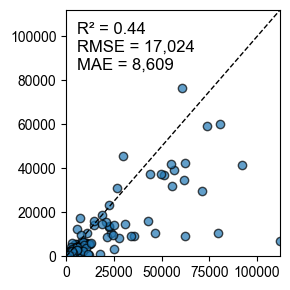

In [8]:
# ============================================================
# 13. OBSERVED VS PREDICTED SCATTER PLOT — AFTER CALIBRATION
# ============================================================

import matplotlib.pyplot as plt


# Set font to Arial
plt.rcParams["font.family"] = "Arial"


# ------------------------------------------------------------
# Metrics dictionary used in the annotation
# ------------------------------------------------------------

metrics_calibration = {
    "R2": r2_calibrated,
    "RMSE": rmse_calibrated,
    "MAE": mae_calibrated,
}


# ------------------------------------------------------------
# Create scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(3, 3))

plt.scatter(
    y_observed,
    y_predicted,
    alpha=0.7,
    edgecolor="k",
)


# ------------------------------------------------------------
# Add 1:1 reference line
# ------------------------------------------------------------

max_val = max(
    float(y_observed.max()),
    float(y_predicted.max()),
)

# Prevent identical zero limits
if max_val <= 0:
    max_val = 1.0

plt.plot(
    [0, max_val],
    [0, max_val],
    "k--",
    linewidth=1,
)


# ------------------------------------------------------------
# Force both axes to start at zero
# ------------------------------------------------------------

plt.xlim(0, max_val)
plt.ylim(0, max_val)


# Optional axis labels
# plt.xlabel("Observed physical two-way PM count")
# plt.ylabel("Predicted physical two-way PM flow")
# plt.title("Observed vs Predicted PM Link Flow")


# ------------------------------------------------------------
# Add validation metrics without a border
# ------------------------------------------------------------

textstr = "\n".join([
    f"R² = {metrics_calibration['R2']:.2f}",
    f"RMSE = {metrics_calibration['RMSE']:,.0f}",
    f"MAE = {metrics_calibration['MAE']:,.0f}",
])

plt.text(
    0.05,
    0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
)


# ------------------------------------------------------------
# Final formatting and saving
# ------------------------------------------------------------

plt.grid(False)
plt.tight_layout()

plt.savefig(
    "observed_vs_predicted_SYD_BRI.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [9]:
# =====================================================
# SAVE OD DEMAND BEFORE AND AFTER CALIBRATION
# =====================================================

from pathlib import Path

OD_DEMAND_OUTPUT = Path(
    "output/SYD_SEA_OD_demand_before_after_calibration.csv"
)

# Create output folder if it does not already exist
OD_DEMAND_OUTPUT.parent.mkdir(
    parents=True,
    exist_ok=True
)

# od_keys contains tuples:
# (origin_node, destination_node)
#
# q0    = PM demand before calibration
# q_hat = PM demand after calibration

od_demand_output = pd.DataFrame({
    "origin_node": [
        od[0]
        for od in od_keys
    ],
    "destination_node": [
        od[1]
        for od in od_keys
    ],
    "demand_before_calibration": q0,
    "demand_after_calibration": q_hat,
})

# Optional change columns
od_demand_output["demand_change"] = (
    od_demand_output["demand_after_calibration"]
    - od_demand_output["demand_before_calibration"]
)

od_demand_output["demand_change_percent"] = np.where(
    od_demand_output["demand_before_calibration"] > 0,
    100.0
    * od_demand_output["demand_change"]
    / od_demand_output["demand_before_calibration"],
    np.nan
)

# Save CSV
od_demand_output.to_csv(
    OD_DEMAND_OUTPUT,
    index=False
)

print(
    "OD demand before/after calibration saved to:",
    OD_DEMAND_OUTPUT
)

print(
    "Number of OD pairs saved:",
    len(od_demand_output)
)

display(
    od_demand_output.head()
)

OD demand before/after calibration saved to: output/SYD_SEA_OD_demand_before_after_calibration.csv
Number of OD pairs saved: 11903


,origin_node,destination_node,demand_before_calibration,demand_after_calibration,demand_change,demand_change_percent
0,10003,2028,1.000000e-12,0.436046,0.436046,4.360459e+13
1,10003,2247,1.000000e-12,237.529020,237.529020,2.375290e+16
2,10003,2543,1.000000e-12,0.359615,0.359615,3.596148e+13
3,10003,2573,1.000000e-12,0.359615,0.359615,3.596148e+13
4,10003,2582,1.000000e-12,0.359615,0.359615,3.596148e+13


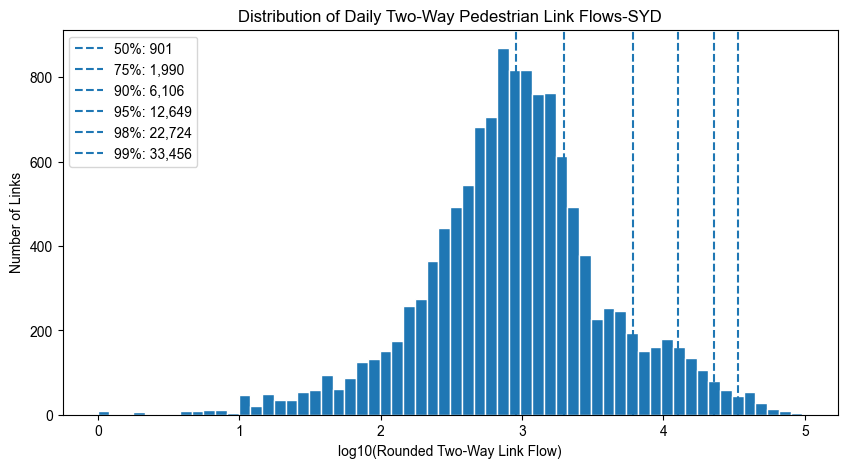

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Distribution of Two-Way Link-Level Flows
# Based on your current BH link_flow GeoDataFrame
# ============================================================

link_flow=gpd.read_file("output/Sydney_weekday_link_level_flow_two_way_BRI.geojson")


FLOW_COL = "flow_hat"

# Remove zero/negative flows for log10
plot_df = link_flow[link_flow[FLOW_COL] > 0].copy()

# Round flow first, then log10
plot_df["rounded_flow"] = plot_df[FLOW_COL].round()

# Remove values rounded to zero
plot_df = plot_df[plot_df["rounded_flow"] > 0].copy()

plot_df["log10_flow"] = np.log10(plot_df["rounded_flow"])

# Percentiles in original flow scale
percentiles = {
    "50%": np.percentile(plot_df["rounded_flow"], 50),
    "75%": np.percentile(plot_df["rounded_flow"], 75),
    "90%": np.percentile(plot_df["rounded_flow"], 90),
    "95%": np.percentile(plot_df["rounded_flow"], 95),
    "98%": np.percentile(plot_df["rounded_flow"], 98),
    "99%": np.percentile(plot_df["rounded_flow"], 99),
}

plt.figure(figsize=(10, 5))

plt.hist(
    plot_df["log10_flow"],
    bins=60,
    edgecolor="white"
)

for label, value in percentiles.items():
    plt.axvline(
        np.log10(value),
        linestyle="--",
        linewidth=1.5,
        label=f"{label}: {value:,.0f}"
    )

plt.xlabel("log10(Rounded Two-Way Link Flow)")
plt.ylabel("Number of Links")
plt.title("Distribution of Daily Two-Way Pedestrian Link Flows-SYD")
plt.grid(False)
plt.legend()

os.makedirs("output", exist_ok=True)
plt.savefig(
    "output/NYC_two_way_link_flow_log_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()